In [5]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit

import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


In [6]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [8]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index[0].date()} to {val_df.index[-1].date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} rows)")


Train: 2018-01-16 to 2023-11-01 (2116 rows)
Val:   2023-11-02 to 2025-01-27 (453 rows)
Test:  2025-01-28 to 2026-04-26 (454 rows)


In [11]:
def hybrid_qrnn_loss(y, q_hybrid, sigma_al, alpha):
    """
    Hybrid QRNN ALD NLL Loss
    y        : observed returns (tensor), shape (T,)
    q_hybrid : hybrid quantile estimate (tensor), shape (T,)
    sigma_al : scale parameter (scalar tensor)
    alpha    : quantile level in (0,1)
    """
    u = y - q_hybrid
    indicator  = (u < 0).float()
    rho_alpha  = u * (alpha - indicator)
    nll = (- torch.log(torch.tensor(alpha * (1 - alpha), dtype=torch.float32))
           + torch.log(sigma_al)
           + rho_alpha / sigma_al)
    return nll.mean()


def compute_hybrid_quantile_location_self_si(y, X, beta1, beta2, beta3, fnn_model, psi):
    """
    Self-lagged hybrid QRNN location -- SI (self-interaction) functional form.
    The CaViaR component uses the previous pure CaViaR output as its autoregressive input.
    SI form: q_t = beta1 * q_{t-1}^S + beta2 * |y_{t-1}| + beta3 * q_{t-1}^S * |y_{t-1}|
    y      : raw log returns (T,)
    X      : normalised features (T, input_dim)
    beta1  : quantile persistence, constrained to (0,1)
    beta2  : magnitude impact, constrained to >=0
    beta3  : interaction term, constrained to >=0
    psi    : mixing weight, constrained to (0,1)
    fnn_model : FNN correction network
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)

    q_caviar_list = [torch.zeros(1)]
    q_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        # CaViaR component -- SI self-lagged: uses previous pure CaViaR output
        abs_y    = torch.abs(y[t-1])
        caviar_t = (beta1 * q_caviar_list[t-1]   # self-lagged
                  + beta2 * abs_y
                  + beta3 * q_caviar_list[t-1] * abs_y)
        q_caviar_list.append(caviar_t)

        # Hybrid combination
        hybrid_t = psi * caviar_t + (1 - psi) * fnn_out[t]
        q_hybrid_list.append(hybrid_t)

    q_caviar = torch.stack(q_caviar_list).squeeze(-1)
    q_hybrid = torch.stack(q_hybrid_list).squeeze(-1)

    return q_hybrid, q_caviar

In [13]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

# Tuning

In [16]:
def compute_hybrid_quantile_location_self_si(y, X, beta1, beta2, beta3, fnn_model, psi):
    """
    Self-lagged hybrid QRNN location -- SI (self-interaction) functional form.
    The CaViaR component uses the previous pure CaViaR output as its autoregressive input.
    SI form: q_t = beta1 * q_{t-1}^S + beta2 * |y_{t-1}| + beta3 * q_{t-1}^S * |y_{t-1}|
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)

    q_caviar_list = [torch.zeros(1)]
    q_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        abs_y    = torch.abs(y[t-1])
        caviar_t = (beta1 * q_caviar_list[t-1]
                  + beta2 * abs_y
                  + beta3 * q_caviar_list[t-1] * abs_y)
        q_caviar_list.append(caviar_t)

        hybrid_t = psi * caviar_t + (1 - psi) * fnn_out[t]
        q_hybrid_list.append(hybrid_t)

    q_caviar = torch.stack(q_caviar_list).squeeze(-1)
    q_hybrid = torch.stack(q_hybrid_list).squeeze(-1)

    return q_hybrid, q_caviar


class HybridQRNN_SI(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.beta3_raw = nn.Parameter(torch.tensor(0.3))     # interaction term
        self.psi_raw   = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = torch.nn.functional.softplus(self.beta2_raw)
        beta3 = torch.nn.functional.softplus(self.beta3_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = torch.nn.functional.softplus(self.sigma_raw)

        # self-lagged SI: uses previous pure CaViaR output
        q_hybrid, q_caviar = compute_hybrid_quantile_location_self_si(
            y, X, beta1, beta2, beta3, self.fnn, psi)

        return q_hybrid, sigma


def compute_crp(y, q, alpha):
    """
    Coverage Ratio Penalty (CRP).
    For alpha <= 0.5: count violations where y <= q (lower tail).
    For alpha >  0.5: count violations where y >  q (upper tail).
    CRP = empirical_coverage / alpha*
    Penalty = (CRP - 1)^2
    """
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective_qrnn(trial, alpha):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)
    model = HybridQRNN_SI(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        crp, crp_penalty = compute_crp(y_val, q_val, alpha)

        beta1 = torch.sigmoid(model.beta1_raw).item()
        beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        beta3 = torch.nn.functional.softplus(model.beta3_raw).item()
        psi   = torch.sigmoid(model.psi_raw).item()
        sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('beta1',       beta1)
    trial.set_user_attr('beta2',       beta2)
    trial.set_user_attr('beta3',       beta3)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"alpha={alpha} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"beta1={beta1:.4f} | beta2={beta2:.4f} | beta3={beta3:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    for rank, t in enumerate(sorted(trials, key=lambda t: t._nll), start=1):
        t._rank_nll = rank

    for rank, t in enumerate(sorted(trials, key=lambda t: t._crp_penalty), start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


# -------------------------
# Run tuning for each alpha level
# -------------------------
alpha_levels              = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed                 = 2026
best_configs_qrnn_si_self = {}  # distinct name for QRNN SI self-lagged

for i, alpha in enumerate(alpha_levels):
    print(f"\n{'='*60}")
    print(f"Tuning QRNN SI Self-lagged for alpha = {alpha} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, a=alpha: objective_qrnn(trial, alpha=a),
                   n_trials=200, show_progress_bar=True)

    best_trial, all_trials = select_best_trial_by_rank(study)

    print(f"\nRanking summary for alpha={alpha}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking to CSV
    ranking_records = []
    for t in all_trials:
        record = {
            'alpha':       alpha,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'beta1':       t.user_attrs['beta1'],
            'beta2':       t.user_attrs['beta2'],
            'beta3':       t.user_attrs['beta3'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    ranking_df.to_csv(f'qrnn_si_self_ranking_alpha_{alpha}.csv', index=False)
    print(f"  Full ranking saved to qrnn_si_self_ranking_alpha_{alpha}.csv")

    best_configs_qrnn_si_self[alpha] = best_trial.params.copy()
    best_configs_qrnn_si_self[alpha]['alpha'] = alpha

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)
    best_model = HybridQRNN_SI(X_train.shape[1], best_configs_qrnn_si_self[alpha])

    if best_configs_qrnn_si_self[alpha]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_qrnn_si_self[alpha]['lr'],
                                     weight_decay=best_configs_qrnn_si_self[alpha]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_qrnn_si_self[alpha]['lr'],
                                      weight_decay=best_configs_qrnn_si_self[alpha]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_qrnn_si_self[alpha]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            q_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_qrnn_si_self[alpha].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_qrnn_loss(y_val, q_val_final, sigma_val_final, alpha).item()
        final_crp, final_crp_penalty = compute_crp(y_val, q_val_final, alpha)

        est_beta1 = torch.sigmoid(best_model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(best_model.beta2_raw).item()
        est_beta3 = torch.nn.functional.softplus(best_model.beta3_raw).item()
        est_psi   = torch.sigmoid(best_model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_qrnn_si_self[alpha]['est_psi']   = est_psi
    best_configs_qrnn_si_self[alpha]['est_sigma']  = est_sigma
    best_configs_qrnn_si_self[alpha]['est_beta1']  = est_beta1
    best_configs_qrnn_si_self[alpha]['est_beta2']  = est_beta2
    best_configs_qrnn_si_self[alpha]['est_beta3']  = est_beta3
    best_configs_qrnn_si_self[alpha]['est_crp']    = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank: {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:   {est_psi:.4f}")
    print(f"Estimated sigma: {est_sigma:.4f}")
    print(f"Estimated beta1: {est_beta1:.4f}")
    print(f"Estimated beta2: {est_beta2:.4f}")
    print(f"Estimated beta3: {est_beta3:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE -- QRNN SI SELF-LAGGED")
print("="*60)
for alpha, config in best_configs_qrnn_si_self.items():
    print(f"alpha={alpha}: {config}")

[I 2026-07-12 17:16:33,187] A new study created in memory with name: no-name-c77fc709-1c57-45ef-8696-a60a566af1f1



Tuning QRNN SI Self-lagged for alpha = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=3.6922 | CRP=0.1766 | CRP_penalty=0.6780 | alpha=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5002 | sigma=0.9737 | beta1=0.7998 | beta2=0.8540 | beta3=0.8540
[I 2026-07-12 17:16:37,285] Trial 0 finished with value: 3.692239999771118 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 3.692239999771118.
  Trial 1: NLL=3.6976 | CRP=0.0883 | CRP_penalty=0.8312 | alpha=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5001 | sigma=0.9738 | beta1=0.7999 | beta2=0.8541 | beta3=0.8541
[I 2026-07-12 17:16:40,494] Trial 1 finished with value: 3.6976048946380615 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'layernor

[I 2026-07-12 18:34:13,283] A new study created in memory with name: no-name-92b18b42-d0dc-45ae-a8de-fe6ecdbaef5a


...

  Trial 0: NLL=1.8913 | CRP=0.0000 | CRP_penalty=1.0000 | alpha=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5431 | sigma=0.3114 | beta1=0.7581 | beta2=0.6623 | beta3=0.6067
[I 2026-07-13 01:22:11,915] Trial 0 finished with value: 1.8912618160247803 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 1.8912618160247803.
  Trial 1: NLL=2.1800 | CRP=0.3532 | CRP_penalty=0.4183 | alpha=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5192 | sigma=0.4182 | beta1=0.7707 | beta2=0.7200 | beta3=0.6783
[I 2026-07-13 01:22:32,046] Trial 1 finished with value: 2.17999005317688 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.04

[I 2026-07-13 06:37:26,956] A new study created in memory with name: no-name-92eae510-da49-49ab-a8e1-662e5765f99f



Best trial (rank-based): #75
  NLL rank: 15 | CRP rank: 6 | Sum: 21
Final NLL:          -2.3472
Final CRP:          1.0155
Final CRP penalty:  0.0002
Best params: {'n_hidden_layers': 1, 'activation': 'gelu', 'dropout': 0.3640747345945453, 'layernorm': False, 'weight_init': 'he', 'lr': 0.049583177145152785, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 2.2081810507688038e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 101}
Estimated psi:   0.9383
Estimated sigma: 0.0024
Estimated beta1: 0.6637
Estimated beta2: 0.0854
Estimated beta3: 0.1150

Tuning QRNN SI Self-lagged for alpha = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=2.4810 | CRP=0.1766 | CRP_penalty=0.6780 | alpha=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5202 | sigma=0.2899 | beta1=0.7357 | beta2=0.6063 | beta3=0.5780
[I 2026-07-13 06:50:20,429] Trial 0 finished with value: 2.480989933013916 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 2.480989933013916.
  Trial 1: NLL=3.6755 | CRP=0.0000 | CRP_penalty=1.0000 | alpha=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5022 | sigma=0.9563 | beta1=0.8010 | beta2=0.8582 | beta3=0.8572
[I 2026-07-13 06:50:39,300] Trial 1 finished with value: 3.6754915714263916 and parameters: {'n_hidden_layers': 1, 'activation': 'elu'


Training final model for alpha = 0.025 (SI self-lagged)
  Epoch 50: train=1.7373, val=1.6890
  Epoch 100: train=-0.5404, val=-0.5321
  Epoch 150: train=-1.0240, val=-1.5990
  Epoch 200: train=-2.0282, val=-2.1069
  Test loss: -2.1301 | Coverage ratio: 5.022 | beta1=0.2934 | beta2=0.0440 | beta3=0.1038 | psi=0.9614 | sigma=0.0015

Training final model for alpha = 0.05 (SI self-lagged)
  Epoch 50: train=0.9543, val=0.9004
  Epoch 100: train=-1.2345, val=-1.4086
  Epoch 150: train=-1.9997, val=-2.1820
  Early stopping at epoch 199
  Test loss: -2.2005 | Coverage ratio: 3.524 | beta1=0.2806 | beta2=0.0454 | beta3=0.1306 | psi=0.9729 | sigma=0.0025

Training final model for alpha = 0.25 (SI self-lagged)
  Epoch 50: train=0.0726, val=-0.0010
  Epoch 100: train=-1.6636, val=-1.4830
  Epoch 150: train=-2.1766, val=-2.3684
  Epoch 200: train=-2.3995, val=-2.3272
  Test loss: -2.6803 | Coverage ratio: 1.665 | beta1=0.4484 | beta2=0.1059 | beta3=0.1731 | psi=0.9509 | sigma=0.0068

Training final

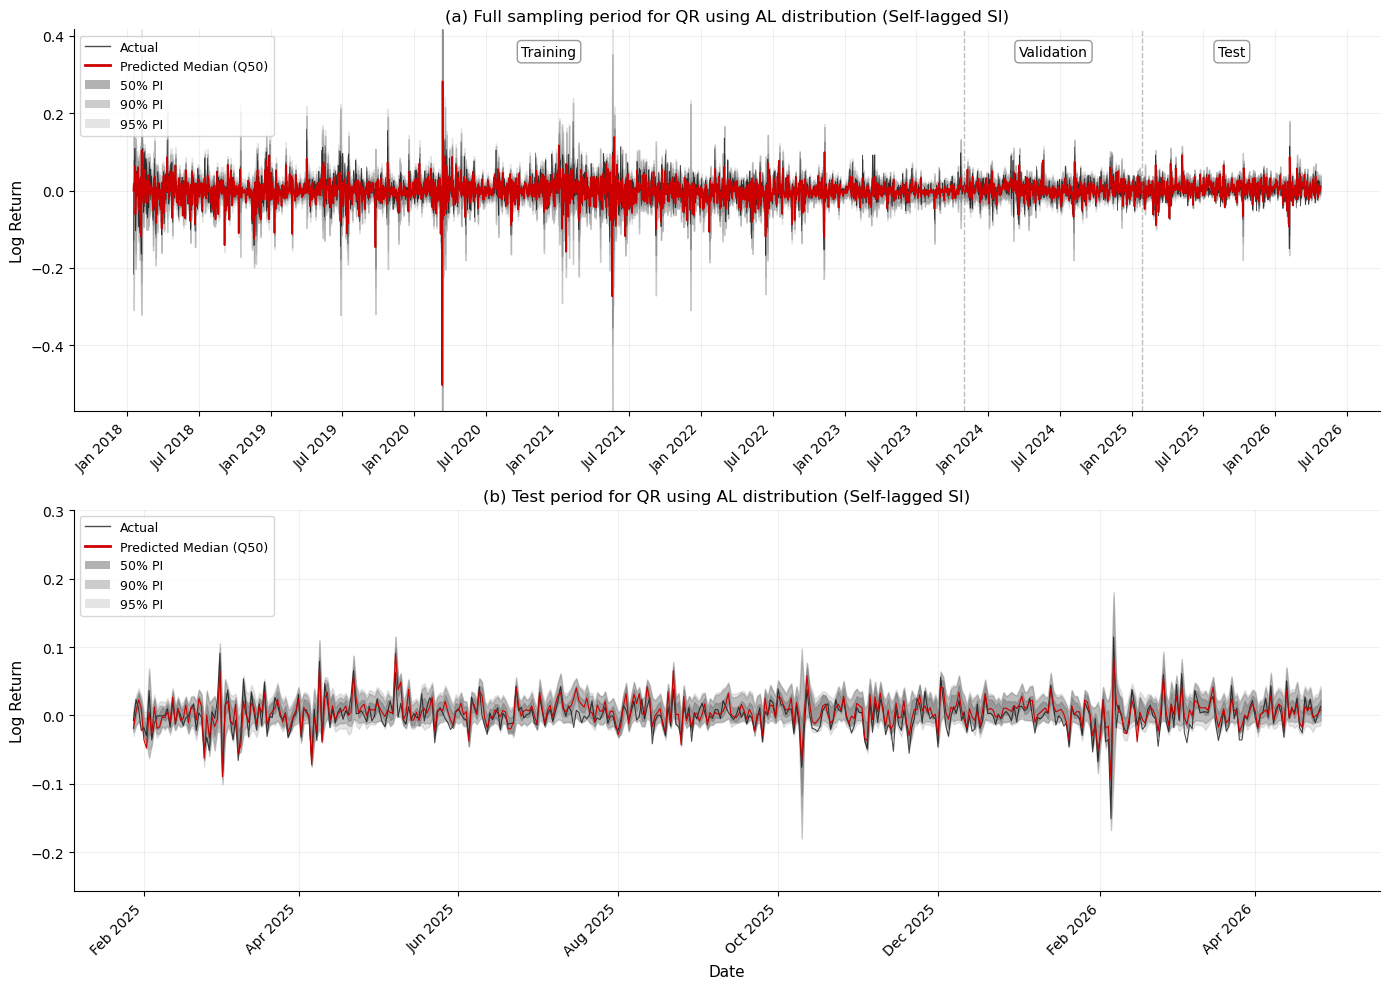

Full period plot saved to hybrid_qrnn_self_si_predictions_full.png
Test period plot saved to hybrid_qrnn_self_si_predictions_test.png

CROSSOVER ANALYSIS -- QRNN Self SI (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):         161     35.46% <-- TAIL
  (0.050, 0.250):          34      7.49%
  (0.250, 0.500):          18      3.96%
  (0.500, 0.750):           0      0.00%
  (0.750, 0.950):          13      2.86%
  (0.950, 0.975):          60     13.22% <-- TAIL
  ------------------------------------------
  Total violations:         286  (10.50% of all pairs)
  Tail violations:          221  (24.34% of tail pairs)


In [18]:
def train_final_model_qrnn_si(alpha, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridQRNN_SI(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        q_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha)

        if alpha <= 0.5:
            coverage = (y_test <= q_test).float().mean().item()
        else:
            coverage = (y_test > q_test).float().mean().item()
        expected       = alpha if alpha <= 0.5 else 1 - alpha
        coverage_ratio = coverage / expected

    with torch.no_grad():
        est_beta1 = torch.sigmoid(model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        est_beta3 = torch.nn.functional.softplus(model.beta3_raw).item()
        est_psi   = torch.sigmoid(model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | Coverage ratio: {coverage_ratio:.3f} | "
          f"beta1={est_beta1:.4f} | beta2={est_beta2:.4f} | beta3={est_beta3:.4f} | "
          f"psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'qrnn_si_self_history_alpha_{alpha}.csv', index=False)

    return model, train_losses, val_losses, q_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all alpha levels
# -------------------------
alpha_levels             = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_qrnn_si_self     = {}

for alpha in alpha_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for alpha = {alpha} (SI self-lagged)")
    print(f"{'='*60}")
    config = best_configs_qrnn_si_self[alpha]
    model, train_losses, val_losses, q_test_pred = train_final_model_qrnn_si(
        alpha, config, y_train, X_train, y_val, X_val, y_test_q, X_test_q
    )
    results_qrnn_si_self[alpha] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'q_test':       q_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols,
                        title_suffix='QR using AL distribution (Self-lagged SI)',
                        save_fname='hybrid_qrnn_self_si_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    alpha_levels = list(best_configs_qrnn_si_self.keys())

    for alpha in alpha_levels:
        model = results_qrnn[alpha]['model']
        model.eval()
        with torch.no_grad():
            q_all, _ = model(y_all, X_all)
            all_preds[alpha] = q_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    y_min, y_max     = y_all_np.min(), y_all_np.max()
    y_range          = y_max - y_min
    y_label          = y_max + 0.25 * y_range
    test_dates       = test_df.index
    y_test_np        = test_df['log_return'].values
    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t        = y_max_t - y_min_t

    # ============================================================
    # Combined two-panel figure
    # ============================================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    ax = axes[0]
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=0.8)
    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {save_fname}")
    plt.show()
    plt.close()

    # ============================================================
    # Panel (a) -- full period separately
    # ============================================================
    fig_a, ax_a = plt.subplots(1, 1, figsize=(14, 5))
    ax_a.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax_a.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax_a.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax_a.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax_a.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax_a.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax_a.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.text(train_df.index[len(train_df)//2], y_label, 'Training',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(val_df.index[len(val_df)//2], y_label, 'Validation',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(test_df.index[len(test_df)//2], y_label, 'Test',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_a.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_a.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax_a.set_ylabel('Log Return', fontsize=11)
    ax_a.grid(True, alpha=0.2)
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    fname_a = save_fname.replace('.png', '_full.png')
    plt.tight_layout()
    plt.savefig(fname_a, dpi=300, bbox_inches='tight')
    print(f"Full period plot saved to {fname_a}")
    plt.close()

    # ============================================================
    # Panel (b) -- test period separately
    # ============================================================
    fig_b, ax_b = plt.subplots(1, 1, figsize=(14, 5))
    ax_b.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax_b.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax_b.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=0.8)
    if have_95:
        ax_b.fill_between(test_dates,
                          all_preds[0.025][train_size + val_size:],
                          all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax_b.fill_between(test_dates,
                          all_preds[0.05][train_size + val_size:],
                          all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax_b.fill_between(test_dates,
                          all_preds[0.25][train_size + val_size:],
                          all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_b.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_b.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_b.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax_b.set_xlabel('Date', fontsize=11)
    ax_b.set_ylabel('Log Return', fontsize=11)
    ax_b.grid(True, alpha=0.2)
    ax_b.spines['top'].set_visible(False)
    ax_b.spines['right'].set_visible(False)
    fname_b = save_fname.replace('.png', '_test.png')
    plt.tight_layout()
    plt.savefig(fname_b, dpi=300, bbox_inches='tight')
    print(f"Test period plot saved to {fname_b}")
    plt.close()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- SI self-lagged
# -------------------------
all_preds_qrnn_si_self, train_size, val_size = plot_two_panel_qrnn(
    results_qrnn_si_self, train_df, val_df, test_df, feature_cols,
    title_suffix='QR using AL distribution (Self-lagged SI)',
    save_fname='hybrid_qrnn_self_si_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='QRNN'):
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]
    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


total_viol, tail_viol = compute_crossovers(
    all_preds_qrnn_si_self, alpha_levels, train_size, val_size,
    model_name='QRNN Self SI'
)

In [20]:
import numpy as np


def compute_hre(y_true, q_pred, alpha):
    """
    Hit Rate Error for quantile evaluation.
    HRE = |mean(1(q_hat > y)) - alpha|
    """
    y        = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    q        = q_pred if isinstance(q_pred, np.ndarray) else np.array(q_pred)
    hit_rate = np.mean(q > y)
    hre      = np.abs(hit_rate - alpha)
    return hre


def compute_test_metrics_qrnn(results, alpha_levels, y_test, X_test, model_name='QRNN'):
    """
    Compute average NLL and HRE on test set across all alpha levels.
    """
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'alpha':>6} {'NLL':>10} {'HRE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    hre_list = []

    for alpha in alpha_levels:
        model = results[alpha]['model']
        model.eval()

        with torch.no_grad():
            q_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha).item()

        q_test_np = q_test.numpy()
        y_test_np = y_test.numpy()

        hre = compute_hre(y_test_np, q_test_np, alpha)

        nll_list.append(test_nll)
        hre_list.append(hre)

        print(f"  {alpha:>6} {test_nll:>10.4f} {hre:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(hre_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average HRE: {np.mean(hre_list):.6f}")

    return np.mean(nll_list), np.mean(hre_list)


# -------------------------
# Test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]

# -------------------------
# Run metrics -- QRNN SI self-lagged
# -------------------------
avg_nll_qrnn_si_self, avg_hre_qrnn_si_self = compute_test_metrics_qrnn(
    results_qrnn_si_self, alpha_levels, y_test_q, X_test_q,
    model_name='QRNN SI Self-lagged'
)


TEST SET METRICS -- QRNN SI Self-lagged
   alpha        NLL            HRE
  ----------------------------------
   0.025    -2.1301       0.100551
    0.05    -2.2005       0.126211
    0.25    -2.6803       0.166300
     0.5    -2.7754       0.185022
    0.75    -2.5573       0.181718
    0.95    -2.3447       0.032379
   0.975    -2.2392       0.020595
  ----------------------------------
    Mean    -2.4182       0.116111

  --> Average NLL: -2.4182
  --> Average HRE: 0.116111


# Cross over dealing

In [23]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# Joint QRNN SI Self-lagged
# One model jointly estimates all seven quantile levels
# ============================================================

alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
alpha_tensor = torch.tensor(alpha_levels, dtype=torch.float32)


class HybridQRNN_SI_Self_Joint(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(alpha_levels)
        self.eps = 1e-6

        # Seven level-specific parameter sets.
        # Initial values match the original single-level model.
        self.beta1_raw = nn.Parameter(torch.full((self.n_levels,), 1.386))
        self.beta2_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.beta3_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.psi_raw   = nn.Parameter(torch.zeros(self.n_levels))
        self.sigma_raw = nn.Parameter(torch.full((self.n_levels,), 0.5))

        # Shared FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            prev_dim = hidden_dim

        # Output:
        # [median, delta12_raw, delta23_raw, delta34_raw,
        #          delta45_raw, delta56_raw, delta67_raw]
        layers.append(nn.Linear(prev_dim, self.n_levels))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu':  nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def reconstruct_fnn_quantiles(self, raw_fnn):
        """
        raw_fnn shape: (T, 7)

        The first output is the median.
        The remaining six outputs become positive adjacent spacings.
        """
        median = raw_fnn[:, 0]
        delta  = F.softplus(raw_fnn[:, 1:]) + self.eps

        f4 = median

        f3 = f4 - delta[:, 2]
        f2 = f3 - delta[:, 1]
        f1 = f2 - delta[:, 0]

        f5 = f4 + delta[:, 3]
        f6 = f5 + delta[:, 4]
        f7 = f6 + delta[:, 5]

        fnn_quantiles = torch.stack(
            [f1, f2, f3, f4, f5, f6, f7],
            dim=1
        )

        return fnn_quantiles

    def forward(self, y, X, initial_caviar=None, initial_y=None):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        beta3 = F.softplus(self.beta3_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        # One shared FNN pass gives all seven neural quantiles.
        raw_fnn       = self.fnn(X)
        fnn_quantiles = self.reconstruct_fnn_quantiles(raw_fnn)

        q_hybrid, q_caviar = compute_hybrid_location_self_si_joint(
            y=y,
            fnn_quantiles=fnn_quantiles,
            beta1=beta1,
            beta2=beta2,
            beta3=beta3,
            psi=psi,
            initial_caviar=initial_caviar,
            initial_y=initial_y
        )

        return q_hybrid, sigma, q_caviar, fnn_quantiles


def compute_hybrid_location_self_si_joint(
    y,
    fnn_quantiles,
    beta1,
    beta2,
    beta3,
    psi,
    initial_caviar=None,
    initial_y=None
):
    """
    Joint self-lagged Hybrid QRNN location -- SI form.

    The pure CaViaR component uses its own previous output:

        q^S_{k,t}
        = beta1_k q^S_{k,t-1}
        + beta2_k |y_{t-1}|
        + beta3_k q^S_{k,t-1}|y_{t-1}|

    The final hybrid output is:

        q^H_{k,t}
        = psi_k q^S_{k,t}
        + (1-psi_k) f_{k,t}

    All seven levels are updated together at each time step.
    """
    T        = len(y)
    n_levels = fnn_quantiles.shape[1]
    zero_row = y.new_zeros(n_levels)

    q_caviar_list = []
    q_hybrid_list = []

    has_initial_state = (
        initial_caviar is not None and
        initial_y is not None
    )

    if (initial_caviar is None) != (initial_y is None):
        raise ValueError(
            "initial_caviar and initial_y must be supplied together."
        )

    previous_caviar = (
        initial_caviar if has_initial_state else zero_row
    )

    for t in range(T):

        # Training sample has no preceding state for t=0.
        # This initial row is excluded from the training loss.
        if t == 0 and not has_initial_state:
            q_caviar_list.append(zero_row)
            q_hybrid_list.append(zero_row)
            continue

        previous_y = initial_y if t == 0 else y[t-1]

        abs_y = torch.abs(previous_y)

        caviar_t = (
            beta1 * previous_caviar
            + beta2 * abs_y
            + beta3 * previous_caviar * abs_y
        )

        hybrid_t = (
            psi * caviar_t
            + (1 - psi) * fnn_quantiles[t]
        )

        q_caviar_list.append(caviar_t)
        q_hybrid_list.append(hybrid_t)

        # Self-lagged: next step uses previous pure CaViaR output.
        previous_caviar = caviar_t

    q_caviar = torch.stack(q_caviar_list, dim=0)
    q_hybrid = torch.stack(q_hybrid_list, dim=0)

    return q_hybrid, q_caviar


# ============================================================
# Joint ALD NLL, HRE and crossover diagnostic
# ============================================================

def hybrid_qrnn_joint_loss(
    y,
    q_hybrid,
    sigma_al,
    alpha_values=alpha_levels
):
    """
    Joint Hybrid QRNN ALD NLL.

    y        : shape (T,)
    q_hybrid : shape (T, 7)
    sigma_al : shape (7,)

    Returns the average NLL across time and all seven levels.
    """
    alpha = torch.tensor(
        alpha_values,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    u         = y.unsqueeze(1) - q_hybrid
    indicator = (u < 0).float()
    rho_alpha = u * (alpha.unsqueeze(0) - indicator)

    nll = (
        -torch.log(alpha * (1 - alpha)).unsqueeze(0)
        + torch.log(sigma_al).unsqueeze(0)
        + rho_alpha / sigma_al.unsqueeze(0)
    )

    return nll.mean()


def compute_hre_joint(
    y,
    q_hybrid,
    alpha_values=alpha_levels
):
    """
    HRE_k = | empirical coverage_k - alpha_k |

    Returns:
        hre_by_level : shape (7,)
        mean_hre     : scalar
    """
    alpha = torch.tensor(
        alpha_values,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    empirical_coverage = (
        y.unsqueeze(1) <= q_hybrid
    ).float().mean(dim=0)

    hre_by_level = torch.abs(empirical_coverage - alpha)
    mean_hre     = hre_by_level.mean()

    return hre_by_level, mean_hre


def compute_crossover_joint(q_hybrid):
    """
    Crossover is a diagnostic only.
    It is not added to the training loss.
    """
    violations = q_hybrid[:, :-1] > q_hybrid[:, 1:]

    pair_counts = violations.sum(dim=0)
    T           = q_hybrid.shape[0]

    total_count = int(pair_counts.sum().item())
    total_rate  = total_count / (T * 6)

    tail_count = int(
        pair_counts[0].item() +
        pair_counts[-1].item()
    )
    tail_rate = tail_count / (T * 2)

    return {
        'pair_counts': [
            int(x) for x in pair_counts.tolist()
        ],
        'total_count': total_count,
        'total_rate':  total_rate,
        'tail_count':  tail_count,
        'tail_rate':   tail_rate
    }


# ============================================================
# Model fitting used inside each Optuna trial
# ============================================================

def fit_joint_qrnn_si_self(
    config,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = HybridQRNN_SI_Self_Joint(
        input_dim=X_train.shape[1],
        config=config
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        q_train, sigma_train, _, _ = model(
            y_train,
            X_train
        )

        # Exclude t=0 because it is only an initialisation row.
        train_loss = hybrid_qrnn_joint_loss(
            y_train[1:],
            q_train[1:],
            sigma_train
        )

        if torch.isnan(train_loss) or torch.isinf(train_loss):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        # Validation continues from the final training state.
        model.eval()
        with torch.no_grad():
            _, sigma_val, q_caviar_train, _ = model(
                y_train,
                X_train
            )

            q_val, _, _, _ = model(
                y_val,
                X_val,
                initial_caviar=q_caviar_train[-1],
                initial_y=y_train[-1]
            )

            val_loss = hybrid_qrnn_joint_loss(
                y_val,
                q_val,
                sigma_val
            )

        scheduler.step(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
        else:
            patience_counter += 1

            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    return model


def evaluate_joint_qrnn_si_self(model):
    model.eval()

    with torch.no_grad():
        _, sigma_val, q_caviar_train, _ = model(
            y_train,
            X_train
        )

        q_val, _, _, fnn_val = model(
            y_val,
            X_val,
            initial_caviar=q_caviar_train[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_qrnn_joint_loss(
            y_val,
            q_val,
            sigma_val
        ).item()

        hre_levels, mean_hre = compute_hre_joint(
            y_val,
            q_val
        )

        final_crossover = compute_crossover_joint(q_val)
        fnn_crossover   = compute_crossover_joint(fnn_val)

        beta1 = torch.sigmoid(model.beta1_raw)
        beta2 = F.softplus(model.beta2_raw)
        beta3 = F.softplus(model.beta3_raw)
        psi   = torch.sigmoid(model.psi_raw)
        sigma = F.softplus(model.sigma_raw) + model.eps

    return {
        'mean_nll':         mean_nll,
        'hre_by_level':     hre_levels.tolist(),
        'mean_hre':         mean_hre.item(),
        'final_crossover':  final_crossover,
        'fnn_crossover':    fnn_crossover,
        'beta1':            beta1.tolist(),
        'beta2':            beta2.tolist(),
        'beta3':            beta3.tolist(),
        'psi':              psi.tolist(),
        'sigma':            sigma.tolist()
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_qrnn_si_self_joint(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation',
            ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float(
            'dropout', 0.0, 0.5
        ),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float(
            'lr', 1e-4, 5e-2, log=True
        ),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}',
            32,
            256
        )

    model = fit_joint_qrnn_si_self(
        config=config,
        max_epochs=200,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_qrnn_si_self(model)

    trial.set_user_attr(
        'mean_nll',
        metrics['mean_nll']
    )
    trial.set_user_attr(
        'mean_hre',
        metrics['mean_hre']
    )
    trial.set_user_attr(
        'hre_by_level',
        metrics['hre_by_level']
    )

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )
    trial.set_user_attr(
        'fnn_crossover_count',
        metrics['fnn_crossover']['total_count']
    )

    trial.set_user_attr('beta1', metrics['beta1'])
    trial.set_user_attr('beta2', metrics['beta2'])
    trial.set_user_attr('beta3', metrics['beta3'])
    trial.set_user_attr('psi',   metrics['psi'])
    trial.set_user_attr('sigma', metrics['sigma'])

    print(
        f"Trial {trial.number}: "
        f"Mean NLL={metrics['mean_nll']:.6f} | "
        f"Mean HRE={metrics['mean_hre']:.6f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%} | "
        f"FNN crossover="
        f"{metrics['fnn_crossover']['total_rate']:.2%}"
    )

    # Optuna requires one scalar objective.
    # Final model selection below uses NLL rank + HRE rank.
    return metrics['mean_nll']


# ============================================================
# Rank trials using Mean NLL rank + Mean HRE rank
# ============================================================

def select_best_trial_by_rank_joint(study):
    trials = [
        t for t in study.trials
        if t.state == optuna.trial.TrialState.COMPLETE
        and t.value is not None
        and np.isfinite(t.value)
        and 'mean_nll' in t.user_attrs
        and 'mean_hre' in t.user_attrs
    ]

    if len(trials) == 0:
        raise RuntimeError(
            "No valid completed Optuna trials."
        )

    for t in trials:
        t._nll = t.user_attrs['mean_nll']
        t._hre = t.user_attrs['mean_hre']

    for rank, t in enumerate(
        sorted(trials, key=lambda x: x._nll),
        start=1
    ):
        t._rank_nll = rank

    for rank, t in enumerate(
        sorted(trials, key=lambda x: x._hre),
        start=1
    ):
        t._rank_hre = rank

    best = min(
        trials,
        key=lambda t: (
            t._rank_nll + t._rank_hre,
            t._nll,
            t._hre,
            t.number
        )
    )

    return best, trials


# ============================================================
# Run one joint Optuna study for all seven levels
# ============================================================

base_seed = 2026

print("\n" + "=" * 70)
print("Tuning Joint QRNN SI Self-lagged for all seven alpha levels")
print("=" * 70)

sampler = TPESampler(seed=base_seed)
study   = optuna.create_study(
    direction='minimize',
    sampler=sampler
)

study.optimize(
    objective_qrnn_si_self_joint,
    n_trials=800,
    show_progress_bar=True
)

best_trial, all_trials = select_best_trial_by_rank_joint(
    study
)


# ============================================================
# Save full trial ranking
# ============================================================

ranking_records = []

for t in all_trials:
    record = {
        'trial':                  t.number,
        'mean_nll':               t._nll,
        'mean_hre':               t._hre,
        'rank_nll':               t._rank_nll,
        'rank_hre':               t._rank_hre,
        'sum_rank':               t._rank_nll + t._rank_hre,
        'final_crossover_count':  t.user_attrs[
            'final_crossover_count'
        ],
        'final_crossover_rate':   t.user_attrs[
            'final_crossover_rate'
        ],
        'tail_crossover_count':   t.user_attrs[
            'tail_crossover_count'
        ],
        'tail_crossover_rate':    t.user_attrs[
            'tail_crossover_rate'
        ],
        'fnn_crossover_count':    t.user_attrs[
            'fnn_crossover_count'
        ]
    }

    for k, alpha in enumerate(alpha_levels):
        suffix = f'alpha_{alpha}'

        record[f'hre_{suffix}'] = (
            t.user_attrs['hre_by_level'][k]
        )
        record[f'beta1_{suffix}'] = (
            t.user_attrs['beta1'][k]
        )
        record[f'beta2_{suffix}'] = (
            t.user_attrs['beta2'][k]
        )
        record[f'beta3_{suffix}'] = (
            t.user_attrs['beta3'][k]
        )
        record[f'psi_{suffix}'] = (
            t.user_attrs['psi'][k]
        )
        record[f'sigma_{suffix}'] = (
            t.user_attrs['sigma'][k]
        )

    record.update(t.params)
    ranking_records.append(record)


ranking_df = pd.DataFrame(ranking_records)
ranking_df = ranking_df.sort_values(
    ['sum_rank', 'mean_nll', 'mean_hre']
)

ranking_df.to_csv(
    'joint_qrnn_si_self_ranking.csv',
    index=False
)


# ============================================================
# Refit the selected configuration
# ============================================================

best_config_si_self = best_trial.params.copy()

best_model_si_self_joint = fit_joint_qrnn_si_self(
    config=best_config_si_self,
    max_epochs=200,
    seed=2026
)

best_metrics_si_self_joint = evaluate_joint_qrnn_si_self(
    best_model_si_self_joint
)


# Save selected model
torch.save(
    {
        'model_state_dict': best_model_si_self_joint.state_dict(),
        'config':           best_config_si_self,
        'alpha_levels':     alpha_levels,
        'validation_metrics': best_metrics_si_self_joint
    },
    'joint_qrnn_si_self_best.pt'
)


# ============================================================
# Final summary
# ============================================================

print("\n" + "=" * 70)
print("TUNING COMPLETE -- JOINT QRNN SI SELF-LAGGED")
print("=" * 70)

print(f"Best trial: #{best_trial.number}")
print(
    f"NLL rank: {best_trial._rank_nll} | "
    f"HRE rank: {best_trial._rank_hre} | "
    f"Sum rank: "
    f"{best_trial._rank_nll + best_trial._rank_hre}"
)

print(
    f"Mean validation NLL: "
    f"{best_metrics_si_self_joint['mean_nll']:.6f}"
)
print(
    f"Mean validation HRE: "
    f"{best_metrics_si_self_joint['mean_hre']:.6f}"
)

print("\nHRE by alpha:")
for alpha, hre in zip(
    alpha_levels,
    best_metrics_si_self_joint['hre_by_level']
):
    print(f"  alpha={alpha:.3f}: HRE={hre:.6f}")

print(
    "\nFinal hybrid crossover: "
    f"{best_metrics_si_self_joint['final_crossover']['total_count']} "
    f"({best_metrics_si_self_joint['final_crossover']['total_rate']:.2%})"
)

print(
    "Tail crossover: "
    f"{best_metrics_si_self_joint['final_crossover']['tail_count']} "
    f"({best_metrics_si_self_joint['final_crossover']['tail_rate']:.2%})"
)

print(
    "FNN crossover count: "
    f"{best_metrics_si_self_joint['fnn_crossover']['total_count']}"
)

print("\nEstimated parameters by level:")
for k, alpha in enumerate(alpha_levels):
    print(
        f"  alpha={alpha:.3f} | "
        f"beta1={best_metrics_si_self_joint['beta1'][k]:.4f} | "
        f"beta2={best_metrics_si_self_joint['beta2'][k]:.4f} | "
        f"beta3={best_metrics_si_self_joint['beta3'][k]:.4f} | "
        f"psi={best_metrics_si_self_joint['psi'][k]:.4f} | "
        f"sigma={best_metrics_si_self_joint['sigma'][k]:.4f}"
    )

print(f"\nBest hyperparameters: {best_config_si_self}")
print(
    "Full ranking saved to: "
    "joint_qrnn_si_self_ranking.csv"
)
print(
    "Best model saved to: "
    "joint_qrnn_si_self_best.pt"
)

[I 2026-07-27 13:13:33,247] A new study created in memory with name: no-name-8c8114b3-1e7e-4b0e-8c6e-17b192656151



Tuning Joint QRNN SI Self-lagged for all seven alpha levels


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: Mean NLL=2.511315 | Mean HRE=0.103579 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-27 13:14:05,667] Trial 0 finished with value: 2.51131534576416 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 2.51131534576416.
Trial 1: Mean NLL=1.475783 | Mean HRE=0.131347 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-27 13:14:35,214] Trial 1 finished with value: 1.475783348083496 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 1.475783348083496.
Trial 2: 

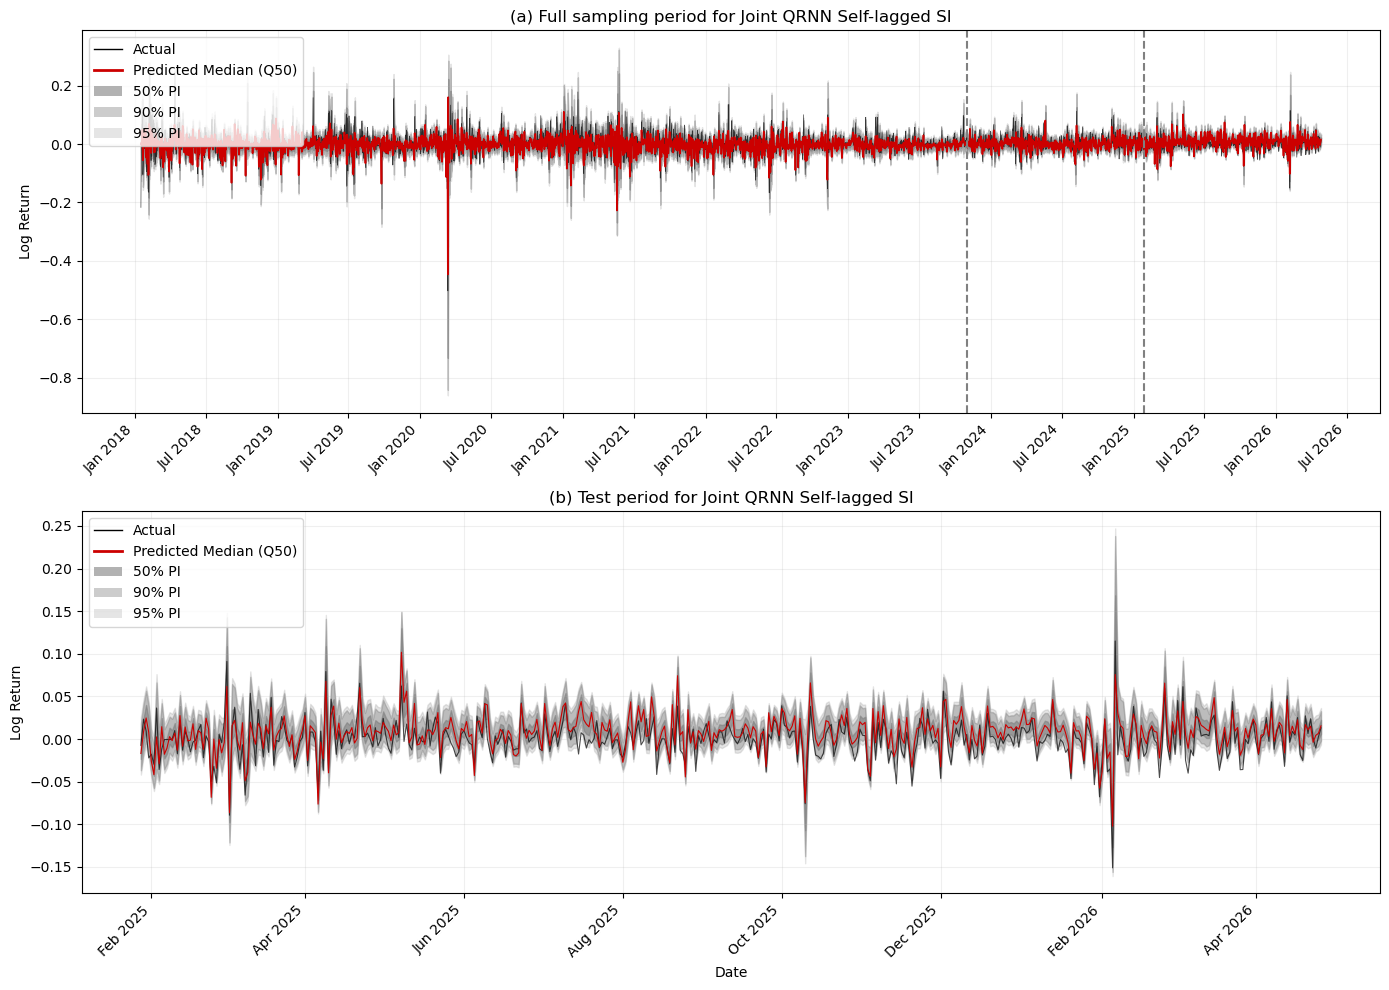

Plot saved to hybrid_qrnn_self_si_joint_predictions.png

TEST METRICS -- JOINT QRNN SI SELF-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -2.309101  0.088106 0.063106
 0.050 -2.358506  0.187225 0.137225
 0.250 -2.642957  0.513216 0.263216
 0.500 -2.679765  0.759912 0.259912
 0.750 -2.641859  0.942731 0.192731
 0.950 -2.357112  0.995595 0.045595
 0.975 -2.241684  1.000000 0.025000

Average NLL: -2.461569
Average HRE: 0.140969

CROSSOVER ANALYSIS -- FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 17 (3.74%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 17 (0.62%)
Tail violations: 0 (0.00%)

CROSSOVER ANALYSIS -- MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)


In [25]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# Joint QRNN SI Self-lagged -- plotting and test evaluation
# Run directly after the joint tuning code
# ============================================================

X_test_q = torch.tensor(
    test_df[feature_cols].values,
    dtype=torch.float32
)
y_test_q = torch.tensor(
    test_df['log_return'].values,
    dtype=torch.float32
)

model = best_model_si_self_joint
model.eval()


# -------------------------
# Sequential predictions
# -------------------------
with torch.no_grad():
    q_train, sigma, caviar_train, fnn_train = model(
        y_train, X_train
    )

    q_val, _, caviar_val, fnn_val = model(
        y_val,
        X_val,
        initial_caviar=caviar_train[-1],
        initial_y=y_train[-1]
    )

    q_test, _, _, fnn_test = model(
        y_test_q,
        X_test_q,
        initial_caviar=caviar_val[-1],
        initial_y=y_val[-1]
    )

q_train_np = q_train.numpy()
q_val_np   = q_val.numpy()
q_test_np  = q_test.numpy()

q_all = np.concatenate(
    [q_train_np, q_val_np, q_test_np],
    axis=0
)

y_all = np.concatenate([
    train_df['log_return'].values,
    val_df['log_return'].values,
    test_df['log_return'].values
])

all_dates = (
    train_df.index
    .append(val_df.index)
    .append(test_df.index)
)

level_index = {
    alpha: k
    for k, alpha in enumerate(alpha_levels)
}

all_preds_qrnn_si_self = {
    alpha: q_all[:, k]
    for k, alpha in enumerate(alpha_levels)
}


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_qrnn_joint(
    all_preds,
    train_df,
    val_df,
    test_df,
    save_fname='hybrid_qrnn_self_si_joint_predictions.png'
):
    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    train_size = len(train_df)
    val_size   = len(val_df)
    test_start = train_size + val_size

    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    legend_elements = [
        Line2D(
            [0], [0],
            color=actual_color,
            lw=1,
            label='Actual'
        ),
        Line2D(
            [0], [0],
            color=pred_color,
            lw=2,
            label='Predicted Median (Q50)'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.6,
            label='50% PI'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.4,
            label='90% PI'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.2,
            label='95% PI'
        )
    ]

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 10)
    )

    # -------------------------
    # Full sample
    # -------------------------
    ax = axes[0]

    ax.plot(
        all_dates,
        y_all,
        color=actual_color,
        linewidth=0.5,
        alpha=0.7
    )
    ax.plot(
        all_dates,
        all_preds[0.500],
        color=pred_color,
        linewidth=1.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.025],
        all_preds[0.975],
        color=pi_color,
        alpha=0.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.050],
        all_preds[0.950],
        color=pi_color,
        alpha=0.4
    )
    ax.fill_between(
        all_dates,
        all_preds[0.250],
        all_preds[0.750],
        color=pi_color,
        alpha=0.6
    )

    ax.axvline(
        train_df.index[-1],
        color='gray',
        linestyle='--'
    )
    ax.axvline(
        val_df.index[-1],
        color='gray',
        linestyle='--'
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=6)
    )
    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax.set_title(
        '(a) Full sampling period for '
        'Joint QRNN Self-lagged SI'
    )
    ax.set_ylabel('Log Return')
    ax.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax.grid(True, alpha=0.2)

    # -------------------------
    # Test sample
    # -------------------------
    ax2 = axes[1]

    ax2.plot(
        test_dates,
        y_test_np,
        color=actual_color,
        linewidth=0.8,
        alpha=0.7
    )
    ax2.plot(
        test_dates,
        all_preds[0.500][test_start:],
        color=pred_color,
        linewidth=0.8
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.025][test_start:],
        all_preds[0.975][test_start:],
        color=pi_color,
        alpha=0.2
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.050][test_start:],
        all_preds[0.950][test_start:],
        color=pi_color,
        alpha=0.4
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.250][test_start:],
        all_preds[0.750][test_start:],
        color=pi_color,
        alpha=0.6
    )

    ax2.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax2.xaxis.set_major_locator(
        mdates.MonthLocator(interval=2)
    )
    plt.setp(
        ax2.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax2.set_title(
        '(b) Test period for '
        'Joint QRNN Self-lagged SI'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Log Return')
    ax2.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(
        save_fname,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print(f'Plot saved to {save_fname}')


plot_two_panel_qrnn_joint(
    all_preds_qrnn_si_self,
    train_df,
    val_df,
    test_df
)


# ============================================================
# Test NLL and HRE
# ============================================================
def compute_test_metrics_joint(
    y_test,
    q_test,
    sigma,
    alpha_levels
):
    records = []

    for k, alpha in enumerate(alpha_levels):
        y = y_test
        q = q_test[:, k]
        sigma_k = sigma[k]

        u = y - q
        indicator = (u < 0).float()
        rho = u * (alpha - indicator)

        nll = (
            -np.log(alpha * (1 - alpha))
            + torch.log(sigma_k)
            + rho / sigma_k
        ).mean().item()

        hit_rate = (
            y <= q
        ).float().mean().item()

        hre = abs(hit_rate - alpha)

        records.append({
            'alpha': alpha,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': hre
        })

    results = pd.DataFrame(records)

    print('\n' + '=' * 60)
    print('TEST METRICS -- JOINT QRNN SI SELF-LAGGED')
    print('=' * 60)
    print(results.to_string(index=False))
    print(f"\nAverage NLL: {results['NLL'].mean():.6f}")
    print(f"Average HRE: {results['HRE'].mean():.6f}")

    results.to_csv(
        'joint_qrnn_si_self_test_metrics.csv',
        index=False
    )

    return results


test_metrics_qrnn_si_self = compute_test_metrics_joint(
    y_test_q,
    q_test,
    sigma,
    alpha_levels
)


# ============================================================
# Test crossover analysis
# ============================================================
def compute_crossovers_joint(
    q_pred,
    levels,
    model_name
):
    q = q_pred.numpy()
    T = len(q)

    total_violations = 0
    tail_violations  = 0

    print('\n' + '=' * 60)
    print(f'CROSSOVER ANALYSIS -- {model_name}')
    print('=' * 60)

    for k in range(len(levels) - 1):
        lo = levels[k]
        hi = levels[k + 1]

        violations = int(
            np.sum(q[:, k] > q[:, k + 1])
        )
        percentage = violations / T * 100

        total_violations += violations

        if k == 0 or k == len(levels) - 2:
            tail_violations += violations
            marker = ' <-- TAIL'
        else:
            marker = ''

        print(
            f'({lo:.3f}, {hi:.3f}): '
            f'{violations} ({percentage:.2f}%){marker}'
        )

    total_rate = (
        total_violations /
        (T * (len(levels) - 1))
    )
    tail_rate = tail_violations / (T * 2)

    print(
        f'\nTotal violations: {total_violations} '
        f'({total_rate:.2%})'
    )
    print(
        f'Tail violations: {tail_violations} '
        f'({tail_rate:.2%})'
    )

    return total_violations, tail_violations


# Final hybrid forecasts: crossing may remain
final_crossovers = compute_crossovers_joint(
    q_test,
    alpha_levels,
    'FINAL HYBRID OUTPUT'
)

# FNN forecasts: crossing should be zero
fnn_crossovers = compute_crossovers_joint(
    fnn_test,
    alpha_levels,
    'MONOTONIC FNN OUTPUT'
)

# Cross over dealing 2

In [28]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Method 2 -- Sequential QRNN SI Self-lagged
# ============================================================

m2_qrnn_self_si_alpha_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]

m2_qrnn_self_si_order = [
    0.500,
    0.750, 0.950, 0.975,
    0.250, 0.050, 0.025
]

m2_qrnn_self_si_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050
}

m2_qrnn_self_si_direction = {
    0.500: 'median',
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower'
}

M2_QRNN_SELF_SI_DELTA = 1e-6
M2_QRNN_SELF_SI_SCALE = 1e-3
M2_QRNN_SELF_SI_PSI_EPS = 1e-4


# ============================================================
# Smooth positive adjustment
# ============================================================

def m2_qrnn_self_si_scaled_softplus(
    value,
    scale=M2_QRNN_SELF_SI_SCALE
):
    return (
        scale
        * F.softplus(value / scale)
    )


# ============================================================
# Method 2 QRNN SI self-lagged model
# ============================================================

class M2SequentialQRNNSISelf(nn.Module):
    def __init__(
        self,
        input_dim,
        config,
        direction='median'
    ):
        super().__init__()

        self.direction = direction
        self.eps = 1e-6

        self.beta1_raw = nn.Parameter(
            torch.tensor(1.386)
        )

        self.beta2_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.beta3_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.psi_raw = nn.Parameter(
            torch.tensor(0.0)
        )

        self.sigma_raw = nn.Parameter(
            torch.tensor(0.5)
        )

        # Add adjacent hybrid forecast as an input
        # for each nonmedian FNN
        fnn_input_dim = (
            input_dim
            if direction == 'median'
            else input_dim + 1
        )

        layers = []
        previous_dim = fnn_input_dim

        for i in range(
            config['n_hidden_layers']
        ):
            hidden_dim = config[
                f'hidden_dim_{i}'
            ]

            layers.append(
                nn.Linear(
                    previous_dim,
                    hidden_dim
                )
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(
                        config['dropout']
                    )
                )

            previous_dim = hidden_dim

        layers.append(
            nn.Linear(previous_dim, 1)
        )

        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(
                        module.weight
                    )

                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(
                        module.weight
                    )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(
        self,
        y,
        X,
        reference=None,
        initial_caviar=None,
        initial_y=None
    ):
        beta1 = torch.sigmoid(
            self.beta1_raw
        )

        beta2 = F.softplus(
            self.beta2_raw
        )

        beta3 = F.softplus(
            self.beta3_raw
        )

        psi = (
            (1.0 - M2_QRNN_SELF_SI_PSI_EPS)
            * torch.sigmoid(self.psi_raw)
        )

        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        if self.direction == 'median':
            fnn_input = X

        else:
            if reference is None:
                raise ValueError(
                    'A reference prediction is required '
                    'for a nonmedian level.'
                )

            fnn_input = torch.cat(
                [
                    X,
                    reference.reshape(-1, 1)
                ],
                dim=1
            )

        raw_fnn = (
            self.fnn(fnn_input)
            .squeeze(-1)
        )

        (
            q_hybrid,
            q_caviar,
            constrained_fnn
        ) = m2_qrnn_self_si_location(
            y=y,
            raw_fnn=raw_fnn,
            beta1=beta1,
            beta2=beta2,
            beta3=beta3,
            psi=psi,
            reference=reference,
            direction=self.direction,
            initial_caviar=initial_caviar,
            initial_y=initial_y
        )

        return (
            q_hybrid,
            sigma,
            q_caviar,
            constrained_fnn
        )


# ============================================================
# Self-lagged SI hybrid location
# ============================================================

def m2_qrnn_self_si_location(
    y,
    raw_fnn,
    beta1,
    beta2,
    beta3,
    psi,
    reference=None,
    direction='median',
    initial_caviar=None,
    initial_y=None
):
    T = len(y)
    zero = y.new_tensor(0.0)

    hybrid_list = []
    caviar_list = []
    fnn_list = []

    if (
        (initial_caviar is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_caviar and initial_y '
            'must be supplied together.'
        )

    has_initial_state = (
        initial_caviar is not None
    )

    previous_caviar = (
        initial_caviar
        if has_initial_state
        else zero
    )

    for t in range(T):
        if (
            t == 0
            and not has_initial_state
        ):
            hybrid_list.append(zero)
            caviar_list.append(zero)
            fnn_list.append(raw_fnn[t])
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        absolute_return = torch.abs(
            previous_y
        )

        # Self-lagged SI recursion
        caviar_t = (
            beta1 * previous_caviar
            + beta2 * absolute_return
            + beta3
            * previous_caviar
            * absolute_return
        )

        if direction == 'median':
            fnn_t = raw_fnn[t]

        elif direction == 'upper':
            fnn_lower_bound = (
                reference[t]
                + M2_QRNN_SELF_SI_DELTA
                - psi * caviar_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_lower_bound
                + m2_qrnn_self_si_scaled_softplus(
                    raw_fnn[t]
                    - fnn_lower_bound
                )
            )

        elif direction == 'lower':
            fnn_upper_bound = (
                reference[t]
                - M2_QRNN_SELF_SI_DELTA
                - psi * caviar_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_upper_bound
                - m2_qrnn_self_si_scaled_softplus(
                    fnn_upper_bound
                    - raw_fnn[t]
                )
            )

        else:
            raise ValueError(
                "direction must be 'median', "
                "'upper' or 'lower'."
            )

        hybrid_t = (
            psi * caviar_t
            + (1.0 - psi) * fnn_t
        )

        hybrid_list.append(hybrid_t)
        caviar_list.append(caviar_t)
        fnn_list.append(fnn_t)

        # Self-lagged update:
        # use previous pure CAViaR output
        previous_caviar = caviar_t

    return (
        torch.stack(hybrid_list),
        torch.stack(caviar_list),
        torch.stack(fnn_list)
    )


# ============================================================
# Original level-specific ALD loss
# ============================================================

def m2_qrnn_self_si_loss(
    y,
    q_hybrid,
    sigma,
    alpha
):
    residual = y - q_hybrid

    indicator = (
        residual < 0
    ).float()

    check_loss = (
        residual
        * (alpha - indicator)
    )

    constant = -torch.log(
        torch.tensor(
            alpha * (1.0 - alpha),
            dtype=q_hybrid.dtype,
            device=q_hybrid.device
        )
    )

    nll = (
        constant
        + torch.log(sigma)
        + check_loss / sigma
    )

    return nll.mean()


# ============================================================
# Hit-rate error
# ============================================================

def m2_qrnn_self_si_compute_hre(
    y,
    q_hybrid,
    alpha
):
    hit_rate = (
        y <= q_hybrid
    ).float().mean().item()

    hre = abs(
        hit_rate - alpha
    )

    return hit_rate, hre


# ============================================================
# Optuna configuration
# ============================================================

def m2_qrnn_self_si_suggest_config(
    trial
):
    config = {
        'n_hidden_layers':
            trial.suggest_int(
                'n_hidden_layers',
                1,
                3
            ),
        'activation':
            trial.suggest_categorical(
                'activation',
                [
                    'relu',
                    'elu',
                    'gelu',
                    'tanh'
                ]
            ),
        'dropout':
            trial.suggest_float(
                'dropout',
                0.0,
                0.5
            ),
        'layernorm':
            trial.suggest_categorical(
                'layernorm',
                [True, False]
            ),
        'weight_init':
            trial.suggest_categorical(
                'weight_init',
                ['glorot', 'he']
            ),
        'lr':
            trial.suggest_float(
                'lr',
                1e-4,
                5e-2,
                log=True
            ),
        'optimizer':
            trial.suggest_categorical(
                'optimizer',
                ['adam', 'adamw']
            ),
        'weight_decay':
            trial.suggest_float(
                'weight_decay',
                0.0,
                1e-4
            ),
        'gradient_clip':
            trial.suggest_categorical(
                'gradient_clip',
                [0.1, 1.0, 5.0]
            ),
        'patience':
            trial.suggest_categorical(
                'patience',
                [10, 20, 30]
            )
    }

    for i in range(
        config['n_hidden_layers']
    ):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    return config


# ============================================================
# Fit one quantile level
# ============================================================

def m2_qrnn_self_si_fit(
    config,
    alpha,
    direction,
    reference_train=None,
    reference_val=None,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = M2SequentialQRNNSISelf(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        (
            q_train,
            sigma,
            _,
            _
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        train_loss = m2_qrnn_self_si_loss(
            y=y_train[1:],
            q_hybrid=q_train[1:],
            sigma=sigma,
            alpha=alpha
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():
            (
                _,
                sigma_val,
                caviar_train,
                _
            ) = model(
                y=y_train,
                X=X_train,
                reference=reference_train
            )

            (
                q_val,
                _,
                _,
                _
            ) = model(
                y=y_val,
                X=X_val,
                reference=reference_val,
                initial_caviar=caviar_train[-1],
                initial_y=y_train[-1]
            )

            val_loss = m2_qrnn_self_si_loss(
                y=y_val,
                q_hybrid=q_val,
                sigma=sigma_val,
                alpha=alpha
            )

        scheduler.step(
            val_loss.item()
        )

        if (
            val_loss.item()
            < best_val_loss
        ):
            best_val_loss = (
                val_loss.item()
            )

            patience_counter = 0

            best_model_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


# ============================================================
# Evaluate one fitted level
# ============================================================

def m2_qrnn_self_si_evaluate(
    model,
    alpha,
    reference_train=None,
    reference_val=None
):
    model.eval()

    with torch.no_grad():
        (
            q_train,
            sigma,
            caviar_train,
            fnn_train
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        (
            q_val,
            _,
            caviar_val,
            fnn_val
        ) = model(
            y=y_val,
            X=X_val,
            reference=reference_val,
            initial_caviar=caviar_train[-1],
            initial_y=y_train[-1]
        )

        val_nll = m2_qrnn_self_si_loss(
            y=y_val,
            q_hybrid=q_val,
            sigma=sigma,
            alpha=alpha
        ).item()

        hit_rate, val_hre = (
            m2_qrnn_self_si_compute_hre(
                y=y_val,
                q_hybrid=q_val,
                alpha=alpha
            )
        )

        beta1 = torch.sigmoid(
            model.beta1_raw
        ).item()

        beta2 = F.softplus(
            model.beta2_raw
        ).item()

        beta3 = F.softplus(
            model.beta3_raw
        ).item()

        psi = (
            (1.0 - M2_QRNN_SELF_SI_PSI_EPS)
            * torch.sigmoid(model.psi_raw)
        ).item()

        sigma_value = (
            F.softplus(model.sigma_raw)
            + model.eps
        ).item()

    return {
        'val_nll': val_nll,
        'hit_rate': hit_rate,
        'val_hre': val_hre,
        'train_prediction':
            q_train.detach(),
        'val_prediction':
            q_val.detach(),
        'train_caviar':
            caviar_train.detach(),
        'val_caviar':
            caviar_val.detach(),
        'train_fnn':
            fnn_train.detach(),
        'val_fnn':
            fnn_val.detach(),
        'beta1': beta1,
        'beta2': beta2,
        'beta3': beta3,
        'psi': psi,
        'sigma': sigma_value
    }


# ============================================================
# Objective factory
# ============================================================

def m2_qrnn_self_si_make_objective(
    alpha,
    direction,
    reference_train,
    reference_val,
    seed
):
    def objective(trial):
        config = (
            m2_qrnn_self_si_suggest_config(
                trial
            )
        )

        model = m2_qrnn_self_si_fit(
            config=config,
            alpha=alpha,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=seed
        )

        if model is None:
            return float('inf')

        metrics = (
            m2_qrnn_self_si_evaluate(
                model=model,
                alpha=alpha,
                reference_train=reference_train,
                reference_val=reference_val
            )
        )

        trial.set_user_attr(
            'val_nll',
            metrics['val_nll']
        )

        trial.set_user_attr(
            'hit_rate',
            metrics['hit_rate']
        )

        trial.set_user_attr(
            'val_hre',
            metrics['val_hre']
        )

        for parameter in [
            'beta1',
            'beta2',
            'beta3',
            'psi',
            'sigma'
        ]:
            trial.set_user_attr(
                parameter,
                metrics[parameter]
            )

        print(
            f"Trial {trial.number}: "
            f"alpha={alpha:.3f} | "
            f"NLL={metrics['val_nll']:.6f} | "
            f"Hit={metrics['hit_rate']:.6f} | "
            f"HRE={metrics['val_hre']:.6f}"
        )

        return metrics['val_nll']

    return objective


# ============================================================
# Rank trials using validation NLL and HRE
# ============================================================

def m2_qrnn_self_si_select_trial(
    study
):
    trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and 'val_nll'
            in trial.user_attrs
            and 'val_hre'
            in trial.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for trial in trials:
        trial._nll = (
            trial.user_attrs['val_nll']
        )

        trial._hre = (
            trial.user_attrs['val_hre']
        )

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._nll
        ),
        start=1
    ):
        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._hre
        ),
        start=1
    ):
        trial._rank_hre = rank

    best_trial = min(
        trials,
        key=lambda item: (
            item._rank_nll
            + item._rank_hre,
            item._nll,
            item._hre,
            item.number
        )
    )

    return best_trial, trials


# ============================================================
# Sequential tuning
# ============================================================

m2_qrnn_self_si_best_configs = {}
m2_qrnn_self_si_final_models = {}
m2_qrnn_self_si_train_predictions = {}
m2_qrnn_self_si_val_predictions = {}
m2_qrnn_self_si_validation_metrics = {}
m2_qrnn_self_si_studies = {}

for level_index, alpha in enumerate(
    m2_qrnn_self_si_order
):
    direction = (
        m2_qrnn_self_si_direction[
            alpha
        ]
    )

    reference_alpha = (
        m2_qrnn_self_si_reference[
            alpha
        ]
    )

    if reference_alpha is None:
        reference_train = None
        reference_val = None

    else:
        reference_train = (
            m2_qrnn_self_si_train_predictions[
                reference_alpha
            ].detach()
        )

        reference_val = (
            m2_qrnn_self_si_val_predictions[
                reference_alpha
            ].detach()
        )

    current_seed = 2026 + level_index

    print('\n' + '=' * 70)
    print(
        'METHOD 2 -- TUNING QRNN SI SELF-LAGGED '
        f'FOR ALPHA = {alpha}'
    )
    print(
        f'Direction: {direction} | '
        f'Reference: {reference_alpha}'
    )
    print('=' * 70)

    sampler = TPESampler(
        seed=current_seed
    )

    study = optuna.create_study(
        direction='minimize',
        sampler=sampler
    )

    objective = (
        m2_qrnn_self_si_make_objective(
            alpha=alpha,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            seed=current_seed
        )
    )

    study.optimize(
        objective,
        n_trials=200,
        show_progress_bar=True
    )

    (
        best_trial,
        valid_trials
    ) = m2_qrnn_self_si_select_trial(
        study
    )

    # Save ranking for this level
    ranking_records = []

    for trial in valid_trials:
        record = {
            'alpha': alpha,
            'trial': trial.number,
            'val_nll': trial._nll,
            'hit_rate':
                trial.user_attrs[
                    'hit_rate'
                ],
            'val_hre': trial._hre,
            'rank_nll':
                trial._rank_nll,
            'rank_hre':
                trial._rank_hre,
            'sum_rank':
                trial._rank_nll
                + trial._rank_hre,
            'beta1':
                trial.user_attrs['beta1'],
            'beta2':
                trial.user_attrs['beta2'],
            'beta3':
                trial.user_attrs['beta3'],
            'psi':
                trial.user_attrs['psi'],
            'sigma':
                trial.user_attrs['sigma']
        }

        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(
        ranking_records
    ).sort_values(
        [
            'sum_rank',
            'val_nll',
            'val_hre'
        ]
    )

    ranking_df.to_csv(
        (
            'method2_sequential_qrnn_si_self_'
            f'ranking_alpha_{alpha}.csv'
        ),
        index=False
    )

    best_config = (
        best_trial.params.copy()
    )

    # Refit selected architecture
    final_model = (
        m2_qrnn_self_si_fit(
            config=best_config,
            alpha=alpha,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=current_seed
        )
    )

    final_metrics = (
        m2_qrnn_self_si_evaluate(
            model=final_model,
            alpha=alpha,
            reference_train=reference_train,
            reference_val=reference_val
        )
    )

    m2_qrnn_self_si_best_configs[
        alpha
    ] = best_config

    m2_qrnn_self_si_final_models[
        alpha
    ] = final_model

    m2_qrnn_self_si_train_predictions[
        alpha
    ] = final_metrics[
        'train_prediction'
    ]

    m2_qrnn_self_si_val_predictions[
        alpha
    ] = final_metrics[
        'val_prediction'
    ]

    m2_qrnn_self_si_validation_metrics[
        alpha
    ] = {
        'val_nll':
            final_metrics['val_nll'],
        'hit_rate':
            final_metrics['hit_rate'],
        'val_hre':
            final_metrics['val_hre'],
        'beta1':
            final_metrics['beta1'],
        'beta2':
            final_metrics['beta2'],
        'beta3':
            final_metrics['beta3'],
        'psi':
            final_metrics['psi'],
        'sigma':
            final_metrics['sigma'],
        'direction':
            direction,
        'reference_alpha':
            reference_alpha,
        'best_trial':
            best_trial.number
    }

    m2_qrnn_self_si_studies[
        alpha
    ] = study

    print(
        f'\nSelected alpha={alpha:.3f}: '
        f"NLL={final_metrics['val_nll']:.6f} | "
        f"HRE={final_metrics['val_hre']:.6f}"
    )


# ============================================================
# Validation crossover check
# ============================================================

m2_qrnn_self_si_val_matrix = torch.stack(
    [
        m2_qrnn_self_si_val_predictions[
            alpha
        ]
        for alpha
        in m2_qrnn_self_si_alpha_levels
    ],
    dim=1
)

m2_qrnn_self_si_val_crossovers = (
    m2_qrnn_self_si_val_matrix[:, :-1]
    > m2_qrnn_self_si_val_matrix[:, 1:]
)

m2_qrnn_self_si_val_pair_counts = (
    m2_qrnn_self_si_val_crossovers
    .sum(dim=0)
)

m2_qrnn_self_si_val_total_crossovers = int(
    m2_qrnn_self_si_val_pair_counts
    .sum()
    .item()
)

m2_qrnn_self_si_val_tail_crossovers = int(
    (
        m2_qrnn_self_si_val_pair_counts[0]
        + m2_qrnn_self_si_val_pair_counts[-1]
    ).item()
)


# ============================================================
# Save all seven fitted models
# ============================================================

m2_qrnn_self_si_saved_models = {}

for alpha in m2_qrnn_self_si_alpha_levels:
    m2_qrnn_self_si_saved_models[
        str(alpha)
    ] = {
        'state_dict':
            m2_qrnn_self_si_final_models[
                alpha
            ].state_dict(),
        'config':
            m2_qrnn_self_si_best_configs[
                alpha
            ],
        'direction':
            m2_qrnn_self_si_direction[
                alpha
            ],
        'reference_alpha':
            m2_qrnn_self_si_reference[
                alpha
            ]
    }

torch.save(
    {
        'alpha_levels':
            m2_qrnn_self_si_alpha_levels,
        'estimation_order':
            m2_qrnn_self_si_order,
        'models':
            m2_qrnn_self_si_saved_models,
        'validation_metrics':
            m2_qrnn_self_si_validation_metrics,
        'validation_crossover_count':
            m2_qrnn_self_si_val_total_crossovers,
        'validation_tail_count':
            m2_qrnn_self_si_val_tail_crossovers,
        'delta':
            M2_QRNN_SELF_SI_DELTA,
        'softplus_scale':
            M2_QRNN_SELF_SI_SCALE
    },
    'method2_sequential_qrnn_si_self_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

m2_qrnn_self_si_average_val_nll = np.mean(
    [
        m2_qrnn_self_si_validation_metrics[
            alpha
        ]['val_nll']
        for alpha
        in m2_qrnn_self_si_alpha_levels
    ]
)

m2_qrnn_self_si_average_val_hre = np.mean(
    [
        m2_qrnn_self_si_validation_metrics[
            alpha
        ]['val_hre']
        for alpha
        in m2_qrnn_self_si_alpha_levels
    ]
)

print('\n' + '=' * 70)
print(
    'METHOD 2 TUNING COMPLETE -- '
    'QRNN SI SELF-LAGGED'
)
print('=' * 70)

print(
    f'Average validation NLL: '
    f'{m2_qrnn_self_si_average_val_nll:.6f}'
)

print(
    f'Average validation HRE: '
    f'{m2_qrnn_self_si_average_val_hre:.6f}'
)

print(
    f'Validation crossover count: '
    f'{m2_qrnn_self_si_val_total_crossovers}'
)

print(
    f'Validation tail crossover count: '
    f'{m2_qrnn_self_si_val_tail_crossovers}'
)

print(
    'Checkpoint saved to '
    'method2_sequential_qrnn_si_self_best.pt'
)

[I 2026-08-03 14:06:13,060] A new study created in memory with name: no-name-c3dc624d-7f76-41c0-94d6-a3a97e7c581c



METHOD 2 -- TUNING QRNN SI SELF-LAGGED FOR ALPHA = 0.5
Direction: median | Reference: None


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: alpha=0.500 | NLL=1.292552 | Hit=0.399558 | HRE=0.100442
[I 2026-08-03 14:06:45,111] Trial 0 finished with value: 1.29255211353302 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.29255211353302.
Trial 1: alpha=0.500 | NLL=0.250881 | Hit=0.538631 | HRE=0.038631
[I 2026-08-03 14:07:23,461] Trial 1 finished with value: 0.25088077783584595 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.25088077783584595.
Trial 2: alpha=0.500 | NLL=1.403010 | Hit=0.498896 | HRE=0.

[I 2026-08-03 15:31:22,704] A new study created in memory with name: no-name-615281d8-2eb5-4139-952c-2ff95fb30ad7


...

Trial 0: alpha=0.050 | NLL=1.985050 | Hit=0.501104 | HRE=0.451104
[I 2026-08-04 15:00:23,078] Trial 0 finished with value: 1.9850503206253052 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9850503206253052.
Trial 1: alpha=0.050 | NLL=0.782734 | Hit=0.501104 | HRE=0.451104
[I 2026-08-04 15:01:11,899] Trial 1 finished with value: 0.7827344536781311 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.782734453

[I 2026-08-04 20:04:49,468] A new study created in memory with name: no-name-6887dbae-e6c2-4253-9618-3f581d3063f4



Selected alpha=0.050: NLL=-2.377182 | HRE=0.000773

METHOD 2 -- TUNING QRNN SI SELF-LAGGED FOR ALPHA = 0.025
Direction: lower | Reference: 0.05


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: alpha=0.025 | NLL=2.490198 | Hit=0.050773 | HRE=0.025773
[I 2026-08-04 20:05:34,552] Trial 0 finished with value: 2.4901983737945557 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.4901983737945557.
Trial 1: alpha=0.025 | NLL=3.395469 | Hit=0.050773 | HRE=0.025773
[I 2026-08-04 20:06:19,559] Trial 1 finished with value: 3.3954689502716064 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 wit

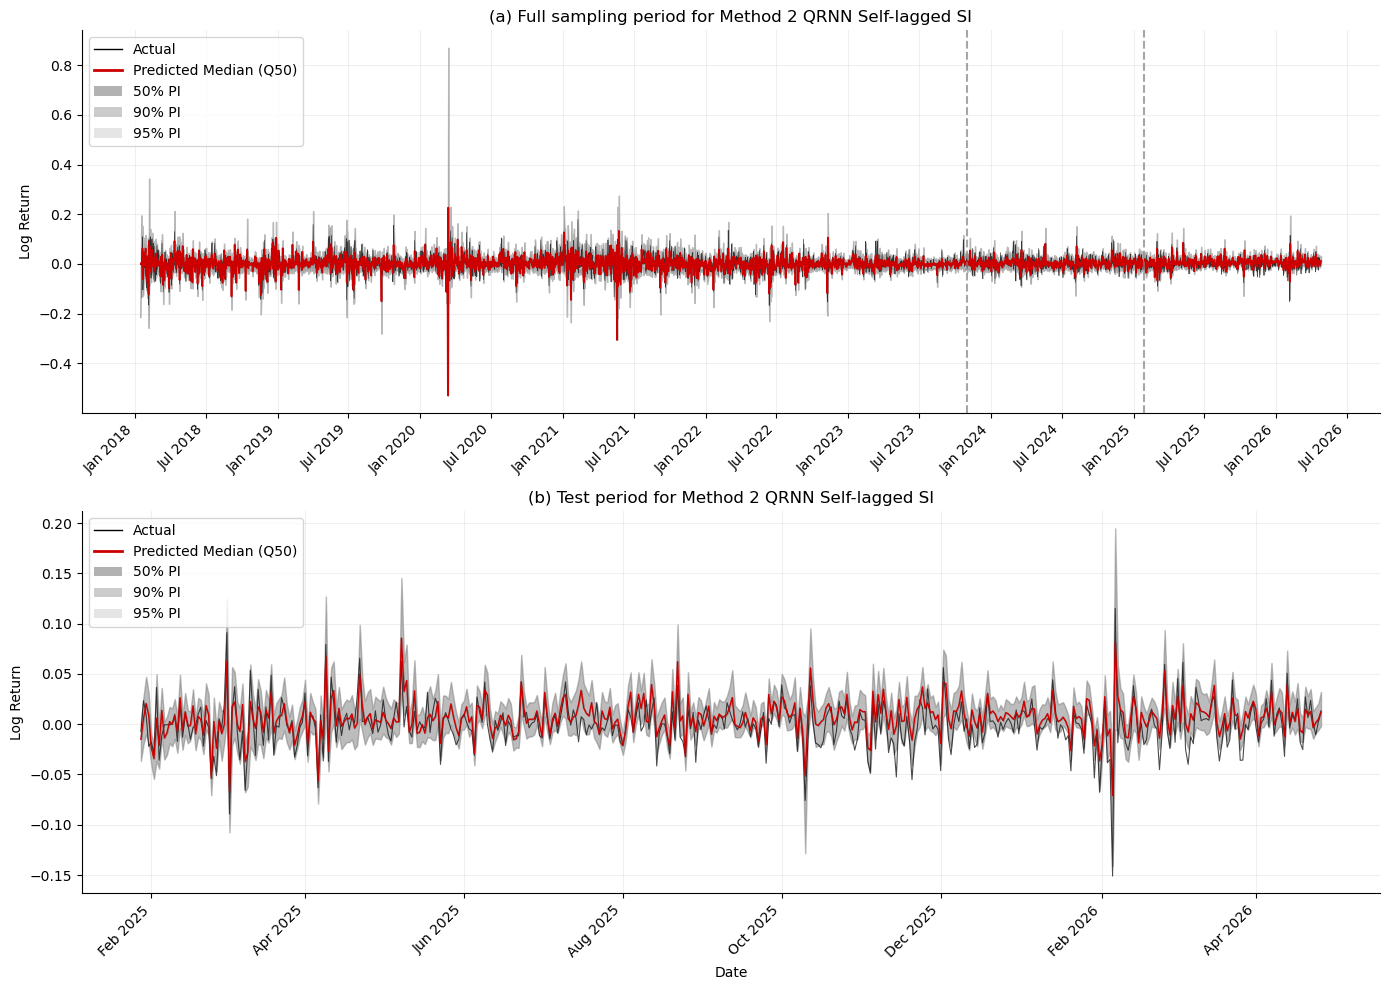

Plot saved to method2_sequential_qrnn_si_self_predictions.png

TEST METRICS -- METHOD 2 QRNN SI SELF-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -1.602922  0.213656 0.188656
 0.050 -2.242972  0.213656 0.163656
 0.250 -2.187529  0.724670 0.474670
 0.500 -2.708048  0.724670 0.224670
 0.750 -2.736067  0.724670 0.025330
 0.950 -2.502083  0.986784 0.036784
 0.975 -2.525485  0.986784 0.011784

Average NLL: -2.357872
Average HRE: 0.160793

CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

Metrics saved to method2_sequential_qrnn_si_self_test_metrics.csv


In [ ]:
# ============================================================
# Plot and evaluate Method 2
# Sequential QRNN SI Self-lagged
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# Generate full-sample predictions sequentially
# ============================================================

m2_qrnn_self_si_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32
)

m2_qrnn_self_si_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32
)

m2_qrnn_self_si_all_predictions = {}
m2_qrnn_self_si_all_caviar = {}
m2_qrnn_self_si_all_fnn = {}
m2_qrnn_self_si_all_sigma = {}

for alpha in m2_qrnn_self_si_order:
    model = m2_qrnn_self_si_final_models[
        alpha
    ]

    reference_alpha = (
        m2_qrnn_self_si_reference[
            alpha
        ]
    )

    if reference_alpha is None:
        reference_prediction = None
    else:
        reference_prediction = (
            m2_qrnn_self_si_all_predictions[
                reference_alpha
            ]
        )

    model.eval()

    with torch.no_grad():
        (
            prediction,
            sigma,
            caviar_output,
            fnn_output
        ) = model(
            y=m2_qrnn_self_si_y_all,
            X=m2_qrnn_self_si_X_all,
            reference=reference_prediction
        )

    m2_qrnn_self_si_all_predictions[
        alpha
    ] = prediction.detach()

    m2_qrnn_self_si_all_caviar[
        alpha
    ] = caviar_output.detach()

    m2_qrnn_self_si_all_fnn[
        alpha
    ] = fnn_output.detach()

    m2_qrnn_self_si_all_sigma[
        alpha
    ] = sigma.detach()


m2_qrnn_self_si_all_preds_np = {
    alpha: prediction.cpu().numpy()
    for alpha, prediction
    in m2_qrnn_self_si_all_predictions.items()
}


# ============================================================
# Sample information
# ============================================================

m2_qrnn_self_si_train_size = len(
    train_df
)

m2_qrnn_self_si_val_size = len(
    val_df
)

m2_qrnn_self_si_test_start = (
    m2_qrnn_self_si_train_size
    + m2_qrnn_self_si_val_size
)

m2_qrnn_self_si_all_dates = df.index
m2_qrnn_self_si_test_dates = test_df.index

m2_qrnn_self_si_y_all_np = (
    df['log_return'].values
)

m2_qrnn_self_si_y_test_np = (
    test_df['log_return'].values
)


# ============================================================
# Plot
# ============================================================

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'

legend_elements = [
    Line2D(
        [0], [0],
        color=actual_color,
        linewidth=1,
        label='Actual'
    ),
    Line2D(
        [0], [0],
        color=median_color,
        linewidth=2,
        label='Predicted Median (Q50)'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.60,
        label='50% PI'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.40,
        label='90% PI'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.20,
        label='95% PI'
    )
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)


# ============================================================
# Panel (a): full sample
# ============================================================

ax = axes[0]

ax.plot(
    m2_qrnn_self_si_all_dates,
    m2_qrnn_self_si_y_all_np,
    color=actual_color,
    linewidth=0.5,
    alpha=0.7
)

ax.plot(
    m2_qrnn_self_si_all_dates,
    m2_qrnn_self_si_all_preds_np[0.500],
    color=median_color,
    linewidth=1.2
)

ax.fill_between(
    m2_qrnn_self_si_all_dates,
    m2_qrnn_self_si_all_preds_np[0.025],
    m2_qrnn_self_si_all_preds_np[0.975],
    color=interval_color,
    alpha=0.20
)

ax.fill_between(
    m2_qrnn_self_si_all_dates,
    m2_qrnn_self_si_all_preds_np[0.050],
    m2_qrnn_self_si_all_preds_np[0.950],
    color=interval_color,
    alpha=0.40
)

ax.fill_between(
    m2_qrnn_self_si_all_dates,
    m2_qrnn_self_si_all_preds_np[0.250],
    m2_qrnn_self_si_all_preds_np[0.750],
    color=interval_color,
    alpha=0.60
)

ax.axvline(
    train_df.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

ax.axvline(
    val_df.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

ax.set_title(
    '(a) Full sampling period for '
    'Method 2 QRNN Self-lagged SI'
)

ax.set_ylabel('Log Return')
ax.grid(True, alpha=0.2)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

ax.legend(
    handles=legend_elements,
    loc='upper left'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# Panel (b): test sample
# ============================================================

ax2 = axes[1]

ax2.plot(
    m2_qrnn_self_si_test_dates,
    m2_qrnn_self_si_y_test_np,
    color=actual_color,
    linewidth=0.8,
    alpha=0.7
)

ax2.plot(
    m2_qrnn_self_si_test_dates,
    m2_qrnn_self_si_all_preds_np[0.500][
        m2_qrnn_self_si_test_start:
    ],
    color=median_color,
    linewidth=1.0
)

ax2.fill_between(
    m2_qrnn_self_si_test_dates,
    m2_qrnn_self_si_all_preds_np[0.025][
        m2_qrnn_self_si_test_start:
    ],
    m2_qrnn_self_si_all_preds_np[0.975][
        m2_qrnn_self_si_test_start:
    ],
    color=interval_color,
    alpha=0.20
)

ax2.fill_between(
    m2_qrnn_self_si_test_dates,
    m2_qrnn_self_si_all_preds_np[0.050][
        m2_qrnn_self_si_test_start:
    ],
    m2_qrnn_self_si_all_preds_np[0.950][
        m2_qrnn_self_si_test_start:
    ],
    color=interval_color,
    alpha=0.40
)

ax2.fill_between(
    m2_qrnn_self_si_test_dates,
    m2_qrnn_self_si_all_preds_np[0.250][
        m2_qrnn_self_si_test_start:
    ],
    m2_qrnn_self_si_all_preds_np[0.750][
        m2_qrnn_self_si_test_start:
    ],
    color=interval_color,
    alpha=0.60
)

ax2.set_title(
    '(b) Test period for '
    'Method 2 QRNN Self-lagged SI'
)

ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.grid(True, alpha=0.2)

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

ax2.legend(
    handles=legend_elements,
    loc='upper left'
)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for axis in axes:
    plt.setp(
        axis.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

plt.tight_layout()

m2_qrnn_self_si_plot_name = (
    'method2_sequential_qrnn_si_self_predictions.png'
)

plt.savefig(
    m2_qrnn_self_si_plot_name,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(
    f'Plot saved to '
    f'{m2_qrnn_self_si_plot_name}'
)


# ============================================================
# Test metrics
# ============================================================

m2_qrnn_self_si_y_test = (
    m2_qrnn_self_si_y_all[
        m2_qrnn_self_si_test_start:
    ]
)

m2_qrnn_self_si_metric_rows = []

for alpha in m2_qrnn_self_si_alpha_levels:
    test_prediction = (
        m2_qrnn_self_si_all_predictions[
            alpha
        ][m2_qrnn_self_si_test_start:]
    )

    sigma = (
        m2_qrnn_self_si_all_sigma[
            alpha
        ]
    )

    test_nll = (
        m2_qrnn_self_si_loss(
            y=m2_qrnn_self_si_y_test,
            q_hybrid=test_prediction,
            sigma=sigma,
            alpha=alpha
        ).item()
    )

    hit_rate, test_hre = (
        m2_qrnn_self_si_compute_hre(
            y=m2_qrnn_self_si_y_test,
            q_hybrid=test_prediction,
            alpha=alpha
        )
    )

    m2_qrnn_self_si_metric_rows.append({
        'alpha': alpha,
        'NLL': test_nll,
        'Hit_Rate': hit_rate,
        'HRE': test_hre
    })


m2_qrnn_self_si_metrics_df = (
    pd.DataFrame(
        m2_qrnn_self_si_metric_rows
    )
)

m2_qrnn_self_si_average_nll = (
    m2_qrnn_self_si_metrics_df[
        'NLL'
    ].mean()
)

m2_qrnn_self_si_average_hre = (
    m2_qrnn_self_si_metrics_df[
        'HRE'
    ].mean()
)

print('\n' + '=' * 68)
print(
    'TEST METRICS -- METHOD 2 '
    'QRNN SI SELF-LAGGED'
)
print('=' * 68)

print(
    m2_qrnn_self_si_metrics_df.to_string(
        index=False
    )
)

print(
    f'\nAverage NLL: '
    f'{m2_qrnn_self_si_average_nll:.6f}'
)

print(
    f'Average HRE: '
    f'{m2_qrnn_self_si_average_hre:.6f}'
)


# ============================================================
# Crossover analysis
# ============================================================

m2_qrnn_self_si_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975)
]

m2_qrnn_self_si_tail_pairs = [
    (0.025, 0.050),
    (0.950, 0.975)
]

m2_qrnn_self_si_total_crossovers = 0
m2_qrnn_self_si_tail_crossovers = 0
m2_qrnn_self_si_crossover_rows = []

print('\n' + '=' * 68)
print(
    'CROSSOVER ANALYSIS -- '
    'FINAL METHOD 2 HYBRID OUTPUT'
)
print('=' * 68)

for lower_alpha, upper_alpha in (
    m2_qrnn_self_si_pairs
):
    lower_prediction = (
        m2_qrnn_self_si_all_predictions[
            lower_alpha
        ][m2_qrnn_self_si_test_start:]
    )

    upper_prediction = (
        m2_qrnn_self_si_all_predictions[
            upper_alpha
        ][m2_qrnn_self_si_test_start:]
    )

    violations = int(
        (
            lower_prediction
            > upper_prediction
        ).sum().item()
    )

    rate = (
        violations
        / len(lower_prediction)
    )

    m2_qrnn_self_si_total_crossovers += (
        violations
    )

    if (
        lower_alpha,
        upper_alpha
    ) in m2_qrnn_self_si_tail_pairs:
        m2_qrnn_self_si_tail_crossovers += (
            violations
        )

    m2_qrnn_self_si_crossover_rows.append({
        'Lower': lower_alpha,
        'Upper': upper_alpha,
        'Violations': violations,
        'Rate': rate
    })

    tail_label = (
        ' <-- TAIL'
        if (
            lower_alpha,
            upper_alpha
        ) in m2_qrnn_self_si_tail_pairs
        else ''
    )

    print(
        f'({lower_alpha:.3f}, '
        f'{upper_alpha:.3f}): '
        f'{violations} '
        f'({100 * rate:.2f}%)'
        f'{tail_label}'
    )


m2_qrnn_self_si_total_rate = (
    m2_qrnn_self_si_total_crossovers
    / (
        len(m2_qrnn_self_si_y_test)
        * 6
    )
)

m2_qrnn_self_si_tail_rate = (
    m2_qrnn_self_si_tail_crossovers
    / (
        len(m2_qrnn_self_si_y_test)
        * 2
    )
)

print(
    f'\nTotal violations: '
    f'{m2_qrnn_self_si_total_crossovers} '
    f'({100 * m2_qrnn_self_si_total_rate:.2f}%)'
)

print(
    f'Tail violations: '
    f'{m2_qrnn_self_si_tail_crossovers} '
    f'({100 * m2_qrnn_self_si_tail_rate:.2f}%)'
)


# ============================================================
# Save metrics
# ============================================================

m2_qrnn_self_si_metrics_df.to_csv(
    (
        'method2_sequential_qrnn_si_self_'
        'test_metrics.csv'
    ),
    index=False
)

pd.DataFrame(
    m2_qrnn_self_si_crossover_rows
).to_csv(
    (
        'method2_sequential_qrnn_si_self_'
        'crossover.csv'
    ),
    index=False
)

print(
    '\nMetrics saved to '
    'method2_sequential_qrnn_si_self_'
    'test_metrics.csv'
)

# Cross over dealing 3

In [32]:
"""Method 3, Specification 1: Hybrid QRNN SI self-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("method3_spacing_qrnn_si_self_results")

# This standalone chunk estimates only the model supplied by the user:
# Hybrid QRNN, symmetric indirect form, self-lagged recursion.
MODELS_TO_RUN = [("qrnn", "si", "self")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "method3_qrnn_si_self_validation_summary.csv", index=False
        )
    print("\nMethod 3 QRNN SI self-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-08-16 14:32:10,792] A new study created in memory with name: no-name-29df6498-b1dd-4e23-8cc0-cefe1501ba2f



METHOD 3 SPACING: QRNN SI SELF
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 14:32:42,411] Trial 0 finished with value: 1.29255211353302 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.29255211353302.
[I 2026-08-16 14:33:13,586] Trial 1 finished with value: 0.25088077783584595 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.25088077783584595.
[I 2026-08-16 14:33:18,148] Trial 2 finished with value: 1.4030100107192993 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': True, 'we

[I 2026-08-16 16:49:19,487] A new study created in memory with name: no-name-02c0d9dd-037e-4ec9-a34f-e6bc44943512


...

[I 2026-08-16 17:32:44,237] Trial 0 finished with value: 1.9721763134002686 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9721763134002686.
[I 2026-08-16 17:32:49,933] Trial 1 finished with value: 0.7031874656677246 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.7031874656677246.
[I 2026-08-16 17:32:53,260] Trial 2 finished with value: 2.917459487915039 and parameters: {'n_hidden_layers': 2, 'activati

[I 2026-08-16 17:40:20,758] A new study created in memory with name: no-name-c4569ae9-ade1-489f-be80-934f451c0a20


Selected trial #181 | val NLL=-2.426967 | calibration=1.015453 | mean delta=0.013949
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 17:40:26,048] Trial 0 finished with value: 2.4899585247039795 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.4899585247039795.
[I 2026-08-16 17:40:31,581] Trial 1 finished with value: 3.3954544067382812 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 2.4899585247039795.
[I 2026-08-16 17:40:34,513] Trial 2 finished with value: 3.5396358966827393 and parameters: {'n_hidden_

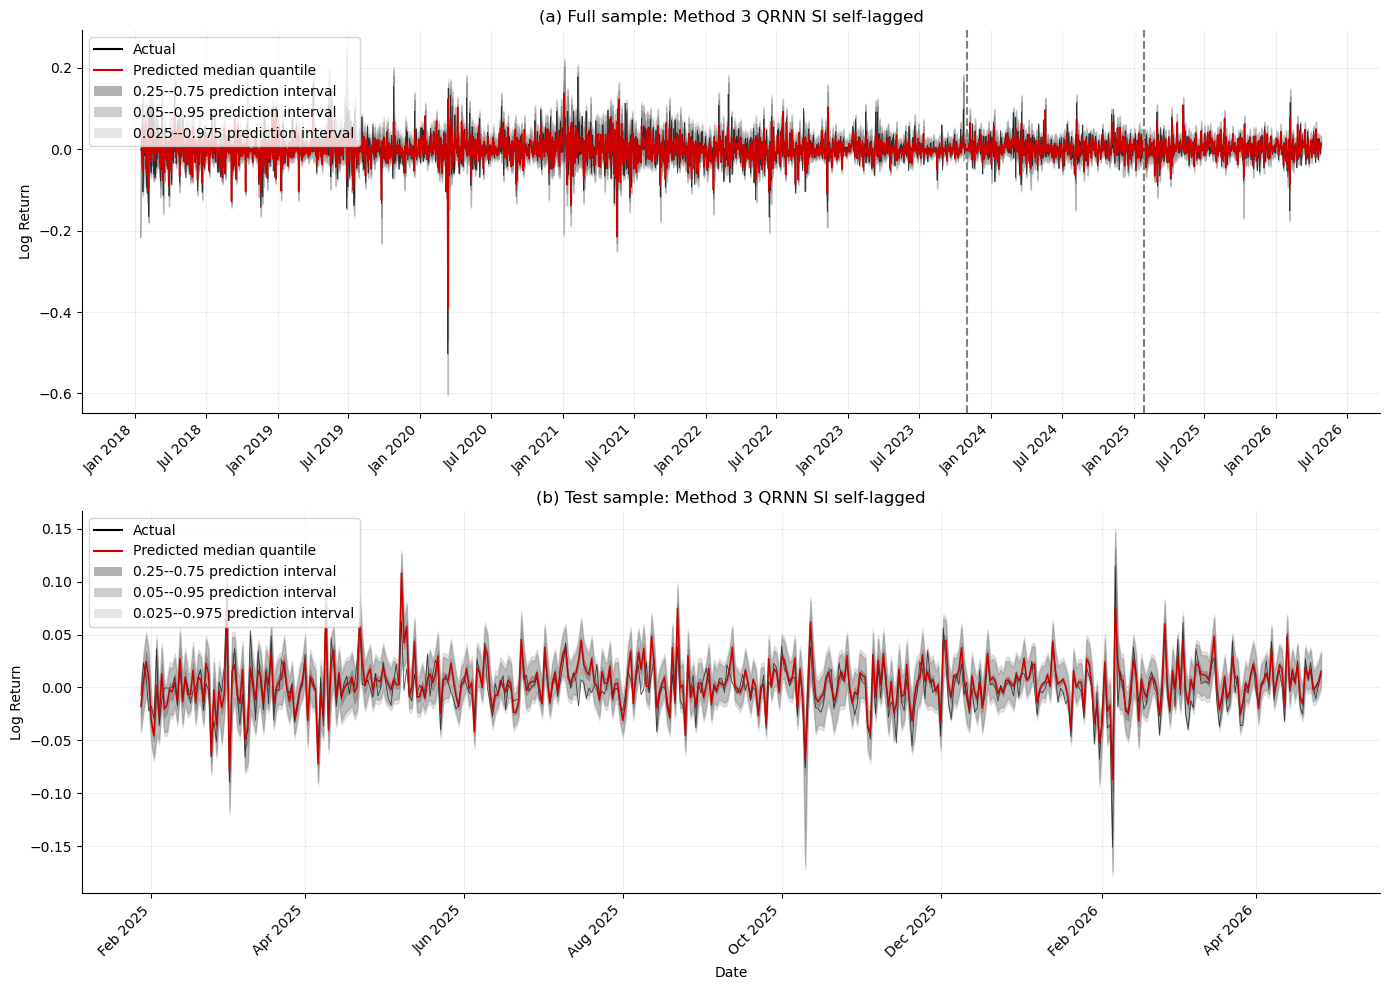


METHOD 3 QRNN SI SELF-LAGGED -- TEST RESULTS
                model  test_T  average_nll  average_hre  crossover  tail
Method 3 QRNN SI Self     454    -2.640912     0.077722          0     0

Per-level results:
 alpha       nll  hit_rate      hre    sigma
 0.025 -2.434246  0.048458 0.023458 0.000895
 0.050 -2.531276  0.090308 0.040308 0.001615
 0.250 -2.680754  0.495595 0.245595 0.004915
 0.500 -2.815379  0.660793 0.160793 0.007698
 0.750 -2.893016  0.773128 0.023128 0.004832
 0.950 -2.619164  0.982379 0.032379 0.001558
 0.975 -2.512551  0.993392 0.018392 0.000911

Learned-spacing diagnostics:
 alpha  reference_alpha direction  mean_delta  min_delta  max_delta  sd_delta  near_zero_count  near_zero_rate
 0.025             0.05     lower    0.003933   0.003820   0.004128  0.000091                0             0.0
 0.050             0.25     lower    0.015736   0.005339   0.085314  0.007478                0             0.0
 0.250             0.50     lower    0.004911   0.001198   0.0181

In [34]:
"""Plot and evaluate Method 3 QRNN SI self-lagged on the test sample.

Run after the tuning/data-preparation code. Expected notebook objects:
df, train_df, val_df, test_df, feature_cols, X_train and Method3SpacingModel.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

MODEL_DIR = Path("method3_spacing_qrnn_si_self_results") / "qrnn_si_self"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_qrnn_si_self_best.pt"
PLOT_PATH = MODEL_DIR / "method3_spacing_qrnn_si_self.png"
METRICS_PATH = MODEL_DIR / "method3_spacing_qrnn_si_self_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "method3_spacing_qrnn_si_self_test_summary.csv"
DELTA_PATH = MODEL_DIR / "method3_spacing_qrnn_si_self_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "method3_spacing_qrnn_si_self_test_predictions.csv"


required_objects = (
    "df", "train_df", "val_df", "test_df", "feature_cols", "X_train"
)
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError("Run the data-preparation cells first. Missing: " + ", ".join(missing))

if "Method3SpacingModel" not in globals():
    from method3_spacing_qrnn_si_self_tuning import Method3SpacingModel

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Run the tuning code first."
    )


# ---------------------------------------------------------------------------
# Reload all seven selected level models
# ---------------------------------------------------------------------------

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "qrnn":
    raise ValueError("The checkpoint is not a QRNN checkpoint.")
if checkpoint.get("form") != "si" or checkpoint.get("lag") != "self":
    raise ValueError("The checkpoint is not the QRNN SI self-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="qrnn",
        form="si",
        lag="self",
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model


# ---------------------------------------------------------------------------
# Generate full-sample forecasts sequentially from the median outwards
# ---------------------------------------------------------------------------

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index

if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")


# ---------------------------------------------------------------------------
# Plot full sample and test sample
# ---------------------------------------------------------------------------

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}
actual_np = df["log_return"].to_numpy()


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(dates, values(0.025), values(0.975), color="#808080", alpha=0.20)
    axis.fill_between(dates, values(0.050), values(0.950), color="#808080", alpha=0.40)
    axis.fill_between(dates, values(0.250), values(0.750), color="#808080", alpha=0.60)
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, actual_np)
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 QRNN SI self-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start)
axes[1].set_title("(b) Test sample: Method 3 QRNN SI self-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median quantile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 prediction interval"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 prediction interval"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 prediction interval"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------------------------
# Test ALD NLL, hit rate and HRE
# ---------------------------------------------------------------------------


def ald_nll(y, quantile, sigma, alpha):
    residual = y - quantile
    alpha_tensor = torch.tensor(alpha, dtype=y.dtype, device=y.device)
    indicator = (residual < 0).to(y.dtype)
    check_loss = residual * (alpha_tensor - indicator)
    return (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma)
        + check_loss / sigma
    ).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    hit_rate = (y_test <= prediction_test).float().mean().item()
    metric_rows.append({
        "alpha": level,
        "nll": ald_nll(y_test, prediction_test, sigmas[level], level).item(),
        "hit_rate": hit_rate,
        "hre": abs(hit_rate - level),
        "sigma": sigmas[level].item(),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)


# ---------------------------------------------------------------------------
# Crossover and learned-spacing diagnostics
# ---------------------------------------------------------------------------

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "alpha": level,
        "reference_alpha": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 QRNN SI Self",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_hre": metrics_df["hre"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)


# ---------------------------------------------------------------------------
# Detailed test predictions and adjacent gaps
# ---------------------------------------------------------------------------

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"q_{level:.3f}"] = predictions[level][test_start:].cpu().numpy()
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)


print("\nMETHOD 3 QRNN SI SELF-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")